## Metodologia

### Strategia próbkowania i podziału zbioru danych
W ramach przygotowania danych do modelowania podjęto następujące kroki:

- Optymalizacja obliczeniowa (10% Sample): Z uwagi na rozmiar zbioru przekraczający 7,7 miliona wierszy, wyodrębniono 10-procentową próbę badawczą. Pozwoliło to na optymalizację zużycia pamięci operacyjnej RAM oraz znaczące przyspieszenie iteracji podczas inżynierii cech, bez utraty zdolności generalizacyjnych.

- Losowanie warstwowe (Stratified Sampling): Zmienna objaśniana Severity charakteryzuje się skrajnym niezbalansowaniem klas. Aby zbiór treningowy był obiektywny, zastosowano losowanie warstwowe, wymuszając w próbce idealne odwzorowanie rozkładu klas z populacji bazowej.

- Zapobieganie dryfowi danych: Próbkę pobrano losowo z całego przedziału 2016-2023. Zrezygnowano z analizy pojedynczego roku, aby zapobiec przeuczeniu modelu na anomaliach rynkowych (np. okres lockdownów w 2020 roku) oraz uwzględnić w uczeniu długoterminowe zmiany w infrastrukturze.

- Prewencja wycieku danych: Podział na zbiór treningowy i testowy został wykonany na surowych danych wejściowych. Gwarantuje to, że wszelkie parametry statystyczne użyte na późniejszym etapie preprocessingu (np. średnie do uzupełnienia braków) będą wyliczone wyłącznie na zbiorze treningowym, zachowując izolację zbioru testowego.

### Analiza kompletności danych przestrzennych (County)
Celem poniższego sprawdzenia jest weryfikacja kompletności kolumny `County` na pełnej populacji danych (przed wyodrębnieniem próbki). Stanowi to kluczowy krok w celu uzasadnienia wyboru hrabstwa jako stabilnego fundamentu terytorialnego do hierarchicznego uzupełnania
 braków w danych pogodowych (zamiast obciążającego obliczeniowo i wrażliwego na rzadkość danych przeszukiwania po dokładnych współrzędnych GPS).

In [1]:
#import pandas as pd
#df = pd.read_csv("C:/Users/Goral/OneDrive/Pulpit/praca inż/US_Accidents_March23.csv") #df to zmienna zawierająca 100% danych
#county_nulls_100 = df['County'].isnull().sum()
#total_rows_100 = len(df)
#percentage_100 = (county_nulls_100 / total_rows_100) * 100

#print(f"Liczba wierszy w całym zbiorze: {total_rows_100}")
#print(f"Liczba nulli w kolumnie County (dla 100% danych): {county_nulls_100}")
#print(f"Procent braków dla County w całej populacji: {percentage_100:.6f}%")

**Wniosek:** Brak jakichkolwiek pustych wartości (0 nulli) w kolumnie `County` w całym zbiorze dowodzi, że jest to w 100% pewny i bezstratny wymiar przestrzenny, idealny do przeprowadzenia bezpiecznego grupowania i uzupełniania braków pogodowych.

## Uruchamiamy poniższy chunk tylko raz!

In [2]:
# import pandas as pd
# import gc # Biblioteka do czyszczenia pamięci RAM
# from sklearn.model_selection import train_test_split

# print("1. Wczytywanie pełnego zbioru danych...")
# file_path = 'US_Accidents_March23.csv' 

# # Wczytujemy zbiór.
# df = pd.read_csv(file_path)
# print(f"Początkowy rozmiar danych: {df.shape[0]} wierszy.")

# print("\n2. Wycinanie 10% reprezentatywnej próbki (Stratified Sampling)...")
# # Dzielimy całość zachowując proporcje kolumny 'Severity'. 
# # df_discarded to te 90%, których nie będziemy na razie używać.
# df_sample, df_discarded = train_test_split(
#     df, 
#     train_size=0.10, 
#     stratify=df['Severity'], 
#     random_state=42 # Zapewnia, że za każdym razem wylosujesz te same 10%
# )

# # Usuwamy z RAMu potężny oryginalny zbiór i niepotrzebne 90%
# del df
# del df_discarded
# gc.collect() # Zmuszamy system do odzyskania pamięci

# print(f"Rozmiar naszej próbki (10%): {df_sample.shape[0]} wierszy.")

# print("\n3. Podział próbki na zbiór Treningowy i Testowy")
# # Z wylosowanych 10% tworzymy ostateczny zbiór do uczenia (np. 80%) i testowania (20%)
# # Tutaj również pilnujemy proporcji Severity!
# df_train, df_test = train_test_split(
#     df_sample, 
#     test_size=0.20, 
#     stratify=df_sample['Severity'], 
#     random_state=42
# )

# print("\n4. Zapisywanie gotowych zbiorów na dysk")
# # Zapisujemy do nowych plików.
# df_train.to_csv('us_accidents_train_10pct.csv', index=False)
# df_test.to_csv('us_accidents_test_10pct.csv', index=False)

# print("\nGotowe! Pliki zapisane.")

In [3]:
import pandas as pd
# Wczytujemy tylko mały zbiór treningowy
df_train = pd.read_csv('us_accidents_train_10pct.csv')

print(f"Liczba wierszy w próbie treningowej: {df_train.shape[0]}")
print(f"Liczba kolumn: {len(df_train.columns)}")

Liczba wierszy w próbie treningowej: 618271
Liczba kolumn: 46


### Standaryzacja nazewnictwa zmiennych
W celu ułatwienia manipulacji danymi oraz zachowania klarowności w rozumieniu, przed przystąpieniem do analizy przeprowadzono standaryzację nazw kolumn. Usunięto znaki specjalne i zamieniono je na podkreślniki (np. zmiana `Temperature(F)` na `Temperature_F`). Zapobiegnie to ewentualnym błędom składniowym w dalszych etapach projektu.

In [4]:
import pandas as pd

print("Nazwy kolumn przed zmianą:")
print(df_train.columns[0:25].tolist())

# Czyszczenie nazw kolumn
df_train.columns = (
    df_train.columns
    .str.replace('(', '_', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('%', 'pct', regex=False)
)

print("\nNazwy kolumn po zmianie:")
print(df_train.columns[0:25].tolist())

Nazwy kolumn przed zmianą:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)']

Nazwy kolumn po zmianie:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance_mi', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature_F', 'Wind_Chill_F', 'Humidity_pct', 'Pressure_in', 'Visibility_mi']


In [5]:
from IPython.display import display

# Wyłączamy limit ukrywania kolumn żeby zobaczyć wszystkie od lewej do prawej
pd.set_option('display.max_columns', None)

display(df_train.sample(10, random_state=42))

# Przywracamy domyślne ustawienia wyświetlania, żeby nie spowalniać edytora
pd.reset_option('display.max_columns')

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance_mi,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature_F,Wind_Chill_F,Humidity_pct,Pressure_in,Visibility_mi,Wind_Direction,Wind_Speed_mph,Precipitation_in,Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
573019,A-3757850,Source1,2,2022-02-02 00:09:05,2022-02-02 02:13:52,42.387711,-83.016053,42.390741,-83.008453,0.441,EB I-94 after Van Dyke,Edsel Ford Fwy E,Detroit,Wayne,MI,48213,US,US/Eastern,KDET,2022-02-02 00:00:00,42.0,39.0,76.0,29.37,10.0,S,5.0,0.00,Cloudy,False,False,False,False,True,False,False,False,False,False,False,False,False,Night,Night,Night,Night
559384,A-6933270,Source1,2,2020-10-16 23:29:00,2020-10-17 01:28:38,36.760371,-76.272057,36.759031,-76.339707,3.746,Incident on I-64 EB near HIGH RISE BRG Left la...,I-64 E,Chesapeake,Chesapeake,VA,23320,US,US/Eastern,KCPK,2020-10-16 23:35:00,55.0,55.0,78.0,30.12,10.0,N,5.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
129742,A-74544,Source2,3,2016-11-23 07:09:45,2016-11-23 07:47:00,32.660152,-117.076317,NaN,NaN,0.010,Right hand shoulder blocked due to accident on...,I-805 S,National City,San Diego,CA,91950,US,US/Pacific,KNRS,2016-11-23 06:56:00,54.0,NaN,80.0,30.14,8.0,East,8.1,NaN,Partly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
57738,A-3708856,Source1,2,2022-05-18 09:21:02,2022-05-18 10:23:00,26.022076,-80.213094,25.986430,-80.229443,2.664,Stationary traffic on FL-91 S - Florida's Tpke...,Florida's Tpke S,Hollywood,Broward,FL,33024,US,US/Eastern,KHWO,2022-05-18 08:53:00,81.0,81.0,67.0,30.04,10.0,CALM,0.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
258385,A-7287684,Source1,4,2019-12-24 07:31:17,2019-12-24 07:58:53,33.428250,-112.068810,33.428330,-112.066080,0.158,Ramp closed to 7th St/Central Ave/Exit 195B - ...,US-60 E,Phoenix,Maricopa,AZ,85004,US,US/Mountain,KPHX,2019-12-24 07:51:00,53.0,53.0,93.0,28.63,10.0,E,10.0,0.01,Light Rain,False,False,False,False,True,False,False,False,False,False,False,False,False,Day,Day,Day,Day
167573,A-2566208,Source2,3,2018-09-06 07:00:50,2018-09-06 07:45:14,42.361767,-71.055298,NaN,NaN,0.000,Restrictions due to accident on I-93 Southboun...,US-1 S,Boston,Suffolk,MA,02109,US,US/Eastern,KBOS,2018-09-06 06:54:00,75.9,NaN,85.0,30.10,10.0,SW,11.5,NaN,Scattered Clouds,False,False,True,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
225529,A-811938,Source2,2,2021-11-19 09:32:46,2021-11-19 10:02:30,42.590809,-71.296471,NaN,NaN,0.000,Accident on MA-3A Boston Rd at Lowell St.,Lowell St,North Billerica,Middlesex,MA,01862,US,US/Eastern,KBED,2021-11-19 09:51:00,46.0,40.0,54.0,29.92,10.0,W,13.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
223253,A-4244683,Source1,2,2022-07-25 23:50:43.000000000,2022-07-26 01:05:44.000000000,29.979452,-95.483305,29.980936,-95.484146,0.114,Incident on SABLERIDGE DR near BRIARCHASE CT D...,Sableridge Dr,Houston,Harris,TX,77014-2144,US,US/Central,KDWH,2022-07-25 23:53:00,83.0,83.0,69.0,29.85,10.0,VAR,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
509933,A-7647045,Source1,2,2017-12-13 16:05:56,2017-12-13 22:05:56,42.993540,-82.447790,42.990210,-82.464760,0.888,At Water St/Lapeer Ave/Exit 274 - Accident. Ri...,I-94 W,Port Huron,St. Clair,MI,48060,US,US/Eastern,KPHN,2017-12-13 15:55:00,19.4,9.5,86.0,29.52,0.5,East,8.1,NaN,Snow,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
225148,A-5022909,Source1,2,2022-06-01 12:27:39,2022-06-01 15:31:33,25.891627,

### Sprawdzamy brakujące dane

In [6]:
#Definicja funkcji raportującej wszystkie kolumny
def sprawdz_wszystkie_kolumny(df):
    braki = df.isnull().sum()
    procent = (braki / len(df)) * 100
    raport = pd.DataFrame({
        'Liczba braków': braki, 
        'Procent braków (%)': procent
    })
    
    # Sortujemy od największej liczby braków
    return raport.sort_values(by='Procent braków (%)', ascending=False)

#Konfiguracja wyświetlania
# Ustawiamy 'None', aby pandas nie limitował liczby wierszy w widoku display
pd.set_option('display.max_rows', None)

#Uruchomienie analizy na zbiorze treningowym
raport_brakow = sprawdz_wszystkie_kolumny(df_train)

#Wyświetlenie pełnej, interaktywnej tabeli
print("Pełny raport braków danych dla wszystkich kolumn:")
display(raport_brakow)

# Przywrócenie domyślnych ustawień
pd.reset_option('display.max_rows')

Pełny raport braków danych dla wszystkich kolumn:


,Liczba braków,Procent braków (%)
End_Lng,272051,44.001902
End_Lat,272051,44.001902
Precipitation_in,176285,28.512578
Wind_Chill_F,159843,25.853226
Wind_Speed_mph,45524,7.363114
Visibility_mi,14193,2.295595
Wind_Direction,14128,2.285082
Humidity_pct,14063,2.274569
Weather_Condition,14019,2.267452
Temperature_F,13236,2.140809


## Wnioski z analizy braków danych 
Na podstawie wygenerowanego raportu można podzielić zmienne na cztery główne grupy, co determinuje strategię czyszczenia danych:

### 1. Współrzędne przestrzenne z istotnymi brakami
- `End_Lng` oraz `End_Lat` (ok. 44% braków).

Decyzja: Wypadki drogowe mogą być zdarzeniami o charakterze odcinkowym (np. rozlane płyny na autostradzie) lub punktowym. Braki we współrzędnych końcowych najczęściej implikują charakter punktowy zdarzenia. Dlatego też, zamiast całkowicie usuwać te zmienne, puste wartości w `End_Lat` i `End_Lng` zostaną zastąpione odpowiadającymi im wartościami ze `Start_Lat` i `Start_Lng`. Zapewni to pełną kompletność danych, co jest kluczowe dla integralności ewentualnych funkcji wizualizacyjnych w docelowej aplikacji mapowej, a jednocześnie pozwoli uniknąć problemów numerycznych na etapie modelowania.

### 2. Kluczowe zmienne pogodowe z dużymi brakami (do uzupełnienia braków)

- `Precipitation_in` (~28.5%) oraz `Wind_Chill_F` (~25.8%).

Decyzja: Z uwagi na znaczenie opadów dla zdarzeń drogowych, kolumn nie można usunąć. Braki w opadach nie mogą być arbitralnie zastępowane zerem, ponieważ mogą wynikać z awarii stacji pomiarowych. Zamiast tego zastosujemy grupowe uzupełnianie braków danych. Braki uzupełnimy medianą opadów dla danego hrabstwa (`County`) wyliczoną dla tego samego miesiąca. Pozwoli to na znacznie precyzyjniejsze odzwierciedlenie lokalnych warunków meteorologicznych. Analogicznie braki w temperaturze odczuwalnej zostaną uzupełnione wartością mediany lub oszacowane na podstawie głównej temperatury.

### 3. Zmienne o niskim i marginalnym poziomie braków (do prostego uzupełnainia braków lub usunięcia wierszy)

- Zmienne pogodowe takie jak `Wind_Speed_mph` (~7.4%), `Visibility_mi` (~2.3%) czy `Temperature_F` (~2.1%). Braki te wynikają prawdopodobnie z chwilowych błędów stacji pomiarowych. Zostaną uzupełnione medianą lub dominantą.

- Zmienne administracyjne i oświetleniowe (np. `Sunrise_Sunset`, `City`, `Zipcode`) mają poniżej 0.5% braków. Usunięcie wierszy/rekordów z tymi brakami będzie statystycznie nieodczuwalne dla modelu uczenia maszynowego.

### 4. Zmienne uznane za kompletne (na podstawie próby badawczej)

- Należy zaznaczyć ważną uwagę: w analizowanej przez nas 10-procentowej próbie badawczej, kluczowe cechy dla projektu (zmienna objaśniana `Severity`, `Start_Lat`, `Start_Lng`, `Start_Time` itd.) wykazują 0% braków danych. Daje to doskonałą stabilność na etapie tworzenia i trenowania modelu. Musimy mieć jednak świadomość, że po przeskalowaniu projektu na pełen zbiór danych (100%), mogą pojawić się w tych kolumnach marginalne braki, które zostaną obsłużone poprzez usunięcie uszkodzonych wierszy.

## Czyszczenie danych

### Implementacja strategii czyszczenia danych 
W celu przygotowania kompletnego zbioru treningowego pod algorytmy uczenia maszynowego, wykonano następujące operacje transformacyjne:

- Korekta współrzędnych końcowych: Puste wartości w kolumnach `End_Lat` i `End_Lng` zostały zastąpione współrzędnymi początkowymi (`Start_Lat`, `Start_Lng`), wychodząc z założenia o punktowym (a nie odcinkowym) charakterze tych konkretnych zdarzeń.

- Logiczne uzupełnianie braków danych: Braki w zmiennej 'Precipitation_in' zastąpiono wartością 0, wychodząc z domenowego założenia, że brak odczytu z czujników opadów w większości przypadków implikuje bezdeszczową pogodę.

- Statystyczne uzupełnianie braków danych: Dla numerycznych zmiennych meteorologicznych o umiarkowanym stopniu braków (m.in. `Wind_Speed_mph`, `Visibility_mi` czy `Temperature_F`) zastosowano uzupełnienie medianą, aby uodpornić rozkład na wartości skrajne. Zmienną opisową 'Weather_Condition' uzupełniono dominantą.

- Czyszczenie resztkowe: Wykonano usunięcie pojedynczych wierszy zawierających braki o udziale poniżej 1%. Działanie to pozwoliło uzyskać 100% kompletność bazy bez ryzyka utraty istotnych wzorców uogólniających.

In [ ]:
print(f"Rozmiar przed czyszczeniem: {df_train.shape[0]} wierszy")

# Korekta współrzędnych końcowych
# Jeśli wypadek nie miał współrzędnych końcowych (brak odcinka), 
# zakładamy, że to wypadek punktowy, czyli koniec = początek.
df_train['End_Lat'] = df_train['End_Lat'].fillna(df_train['Start_Lat'])
df_train['End_Lng'] = df_train['End_Lng'].fillna(df_train['Start_Lng'])

############################################################################
## 1.Usuwamy kolumny z krytycznymi brakami
#kolumny_do_usuniecia = ['End_Lat', 'End_Lng']
#df_train = df_train.drop(columns=kolumny_do_usuniecia, errors='ignore')
##############################################################################

# 1. Zaawansowane szacowanie opadów (County + Miesiąc)
# Aby wyciągnąć miesiąc, musimy najpierw przekonwertować datę
df_train['Start_Time'] = pd.to_datetime(df_train['Start_Time'], format='mixed', errors='coerce')
df_train['Month'] = df_train['Start_Time'].dt.month

# Wypełnianie braków medianą dla danego hrabstwa i miesiąca
df_train['Precipitation_in'] = df_train.groupby(['County', 'Month'])['Precipitation_in'].transform(lambda x: x.fillna(x.median()))

# Fallback! (Jeśli w jakimś małym hrabstwie cały miesiąc nie miał danych, wstawiamy 0)
df_train['Precipitation_in'] = df_train['Precipitation_in'].fillna(0)


# 2. Szacowanie pozostałych danych pogodowych (Mediana)
weather_numeric_cols = [
    'Wind_Chill_F', 'Wind_Speed_mph', 'Visibility_mi', 
    'Humidity_pct', 'Temperature_F', 'Pressure_in'
]

for col in weather_numeric_cols:
    col_median = df_train[col].median()
    df_train[col] = df_train[col].fillna(col_median)


# 3. Szacowanie danych tekstowych (Najczęstsza wartość) uzupełniamy dominantą
most_frequent_weather = df_train['Weather_Condition'].mode()[0]
df_train['Weather_Condition'] = df_train['Weather_Condition'].fillna(most_frequent_weather)


# 4. Czyszczenie resztkowe
df_train = df_train.dropna()

print(f"Rozmiar po czyszczeniu: {df_train.shape[0]} wierszy")
print(f"Całkowita liczba braków w zbiorze: {df_train.isnull().sum().sum()}")

Rozmiar przed czyszczeniem: 618271 wierszy


C:\Users\Goral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Goral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Goral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Goral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarnin

Rozmiar po czyszczeniu: 601687 wierszy
Całkowita liczba braków w zbiorze: 0


### Strategia Wizualizacji i Eksploracji Zmiennych (EDA)

Z uwagi na dużą liczbę cech w oryginalnym zbiorze danych, do eksploracyjnej analizy wizualnej (EDA) wytypowano podzbiór zmiennych, które mają kluczowe znaczenie z perspektywy uwarunkowań wypadków drogowych.

**1. Zmienne omijane na tym etapie:**
* `ID`, `Description`: Zmienne te wykluczono z podstawowej analizy wizualnej ze względu na ich całkowitą unikalność i tekstowy charakter. Należy jednak zaznaczyć, że zmienna `ID` wykorzystywana jest jako klucz do mapowania przestrzennego wypadków.
* `City`, `Zipcode`: Zmienne przestrzenne posiadające tysiące unikalnych wartości. Ze względu na trudności w czytelnej prezentacji na wykresach dwuwymiarowych, zrezygnowano z ich wizualizacji na rzecz analizy agregatów wyższego rzędu, takich jak stan (`State`).
* `Start_Time`: Surowy format daty i czasu (np. "2021-03-12 08:30:00"). Wygeneruje nieczytelny szum. Zmienna ta będzie analizowana wizualnie dopiero na etapie Inżynierii Cech (po wyodrębnieniu samej "godziny" i "dnia tygodnia").

**2. Zmienne wytypowane do analizy na wykresach:**
* **Zmienna docelowa:** `Severity` – w celu potwierdzenia układu klas po czyszczeniu.
* **Kluczowe dane atmosferyczne:** `Temperature_F` oraz `Visibility_mi` – analiza za pomocą histogramów z linią trendu.
* **Stan pogody (Kategorie):** `Weather_Condition` – wizualizacja ograniczona wyłącznie do TOP 10 najczęstszych zjawisk dla zachowania czytelności osi.
* **Infrastruktura drogowa:** `Traffic_Signal` oraz `Crossing` – wykresy binarne pokazujące relację występowania wypadków względem kluczowych punktów na drodze.
* **Współrzędne wypadków:** `Start_Lat` oraz `Start_Lng`: Ze względu na ciągły i przestrzenny charakter tych współrzędnych, wykluczono je ze standardowej analizy. Stanowią one jednak kluczowy element, który zostanie wykorzystany w dalszej części raportu wyłącznie do bezpośredniego, geograficznego renderowania mapy gęstości wypadków.

### Redefinicja problemu badawczego (Podejście Iteracyjne): Klasyfikacja Binarna i Analiza Przestrzenna
Zgodnie z dobrymi praktykami inżynierii uczenia maszynowego, analizę rozpoczęto od uproszczenia problemu. Zamiast natychmiastowego budowania modelu wieloklasowego dla wszystkich 4 oryginalnych kategorii (`Severity`), zdecydowano się na krok pośredni – **klasyfikację binarną**.
Takie podejście iteracyjne pozwala na zbudowanie solidnego punktu odniesienia. Sprawdzimy, czy modele potrafią najpierw oddzielić wypadki ogólnie "Groźne" od "Niegroźnych", zanim postawimy przed nimi znacznie trudniejsze zadanie rozróżnienia precyzyjnego poziomu ciężkości zjawiska. Dodatkowym czynnikiem wspierającym ten krok był ogromny brak balansu klas w oryginalnym zbiorze (znaczna dominacja kategorii 2). 

Przyjmujemy podział:
* **Klasa 0 (Niegroźne):** Wypadki lekkie/umiarkowane (oryginalne Severity 1 i 2).
* **Klasa 1 (Groźne):** Wypadki ciężkie/poważne (oryginalne Severity 3 i 4).

W docelowej fazie projektu, skuteczność tego podejścia zostanie skonfrontowana z modelami uczonymi na pełnym, 4-klasowym spektrum danych.

Poniższa wizualizacja to tzw. "mapa bez mapy"  jako Scatter Plot. Osie X i Y reprezentują współrzędne geograficzne zdarzeń, co naturalnie odtwarza kontury Stanów Zjednoczonych. Pokolorowanie punktów według nowej, binarnej zmiennej docelowej pozwala zidentyfikować obszary o podwyższonym ryzyku groźnych wypadków.

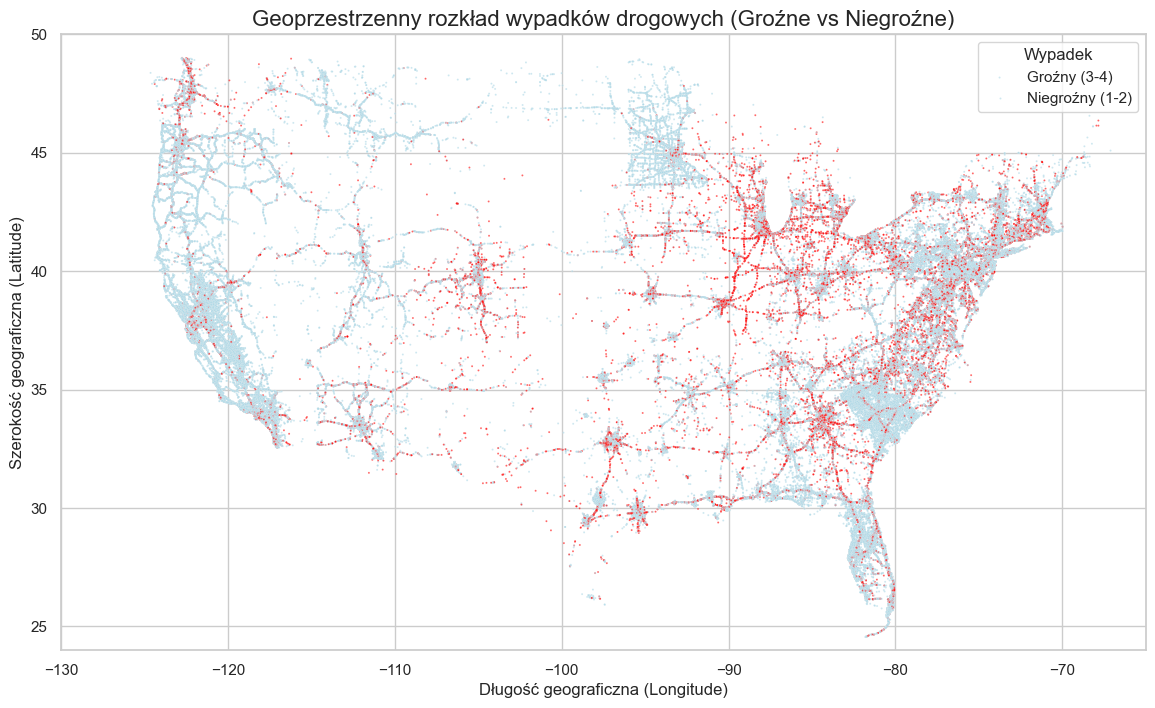

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Tworzenie zmiennej binarnej
# 0 -> Niegroźne (Severity 1 i 2)
# 1 -> Groźne (Severity 3 i 4)
df_train['Severity_Binary'] = df_train['Severity'].apply(lambda x: 0 if x in [1, 2] else 1)

# Wizuacja Scatter plot "mapa bez mapy"
plt.figure(figsize=(14, 8))
# Używamy s=2 (wielkość punktu) oraz alpha=0.6 (przezroczystość)
sns.scatterplot(
    data=df_train, 
    x='Start_Lng', 
    y='Start_Lat', 
    hue='Severity_Binary', 
    palette={0: 'lightblue', 1: 'red'},
    s=2, 
    alpha=0.6
)

plt.title('Geoprzestrzenny rozkład wypadków drogowych (Groźne vs Niegroźne)', fontsize=16)
plt.xlabel('Długość geograficzna (Longitude)')
plt.ylabel('Szerokość geograficzna (Latitude)')
# Ograniczenie osi do kontynentalnych USA
plt.xlim(-130, -65)
plt.ylim(24, 50)
plt.legend(title='Wypadek', labels=['Groźny (3-4)', 'Niegroźny (1-2)'])
plt.show()

### Wnioski z Analizy Przestrzennej (Geospatial EDA)
Wykres "mapy bez mapy" ujawnia istotne wzorce rozkładu wypadków na terenie USA:

- Sieć głównych tras: Kropki naturalnie odwzorowują kluczowe autostrady. Zdecydowana większość zdarzeń ma miejsce wzdłuż głównych węzłów komunikacyjnych, omijając górzyste i słabo zaludnione obszary środkowego-zachodu (Midwest i rejony Gór Skalistych).

- Koncentracja wypadków groźnych (Klasa 1): Uwagę zwraca potężne skupisko czerwonych punktów (wypadków ciężkich) we wschodniej połowie Stanów Zjednoczonych (w szczególności pas wybrzeża wschodniego, Floryda oraz rejon Wielkich Jezior).

- Paradoks Kalifornii: Znaczącym wnioskiem jest sytuacja na Zachodnim Wybrzeżu (szczególnie w Kalifornii). Choć zagęszczenie wypadków jest tam ekstremalnie wysokie (jasnoniebieskie skupiska w rejonie LA czy San Francisco), to proporcjonalnie znajduje się tam niewiele wypadków sklasyfikowanych jako groźne (czerwone). Może to wynikać z wiecznych korków w tych aglomeracjach, które drastycznie obniżają średnią prędkość pojazdów, przekształcając potencjalnie groźne wypadki w stłuczki i "zderzenia parkingowe".

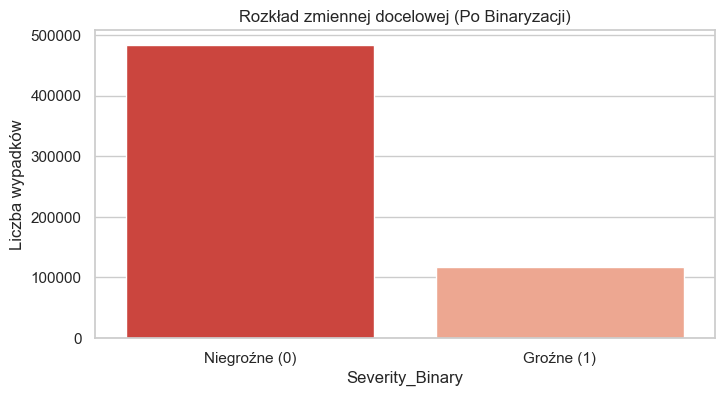

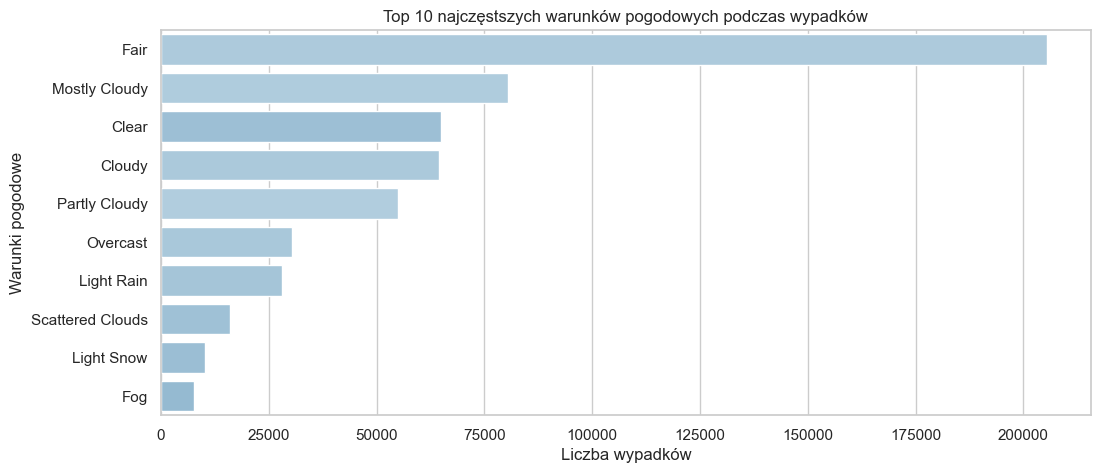

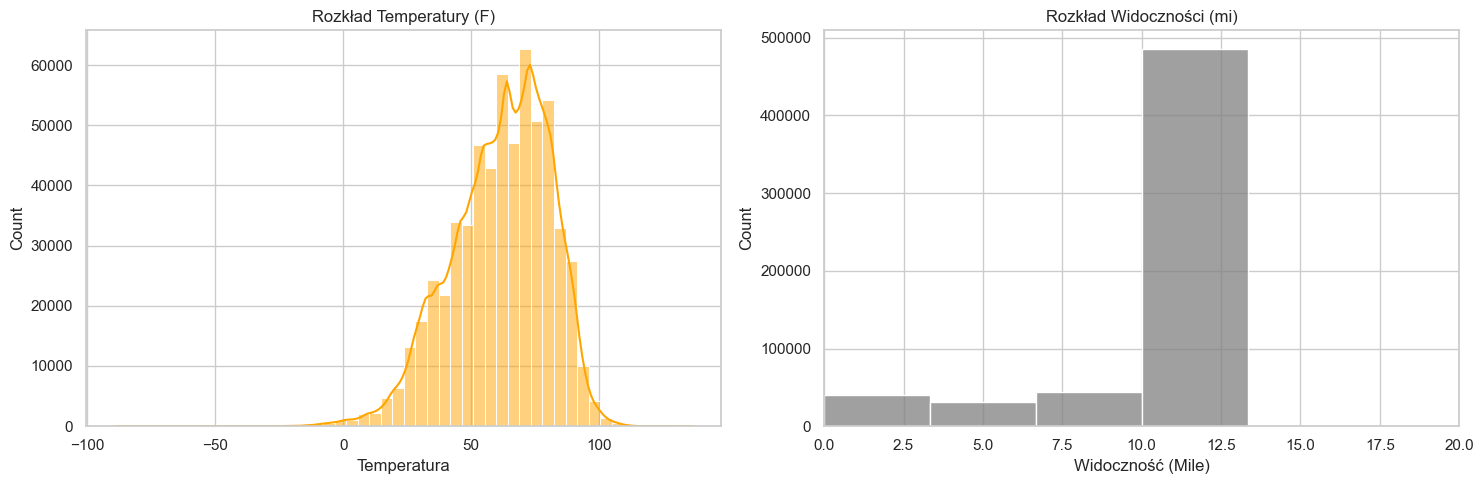

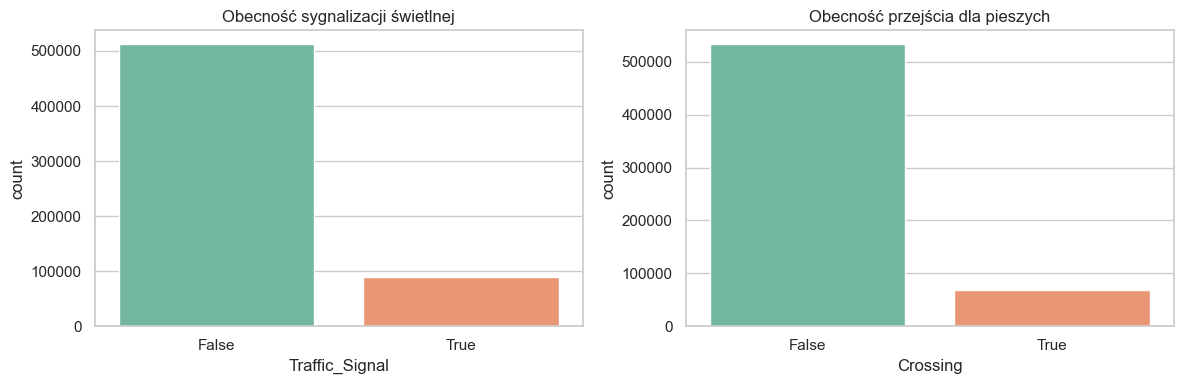

In [9]:
# 1. Zmienna celu (Binarne Severity)
plt.figure(figsize=(8, 4))
sns.countplot(data=df_train, x='Severity_Binary', hue='Severity_Binary', palette='Reds_r', legend=False)
plt.title('Rozkład zmiennej docelowej (Po Binaryzacji)')
plt.xticks([0, 1], ['Niegroźne (0)', 'Groźne (1)'])
plt.ylabel('Liczba wypadków')
plt.show()

# 2. Pogoda
top_10_weather = df_train['Weather_Condition'].value_counts().nlargest(10).index

plt.figure(figsize=(12, 5))
sns.countplot(data=df_train, y='Weather_Condition', hue='Weather_Condition', 
              order=top_10_weather, palette='Blues_d', legend=False)
plt.title('Top 10 najczęstszych warunków pogodowych podczas wypadków')
plt.xlabel('Liczba wypadków')
plt.ylabel('Warunki pogodowe')
plt.show()

# 3. Pogoda: numeryczne (temperatura i widoczność)
fig, ax = plt.subplots(1, 2, figsize=(15, 5)) 

sns.histplot(df_train['Temperature_F'], bins=50, kde=True, color='orange', ax=ax[0])
ax[0].set_title('Rozkład Temperatury (F)')
ax[0].set_xlabel('Temperatura')

sns.histplot(df_train['Visibility_mi'], bins=30, kde=False, color='gray', ax=ax[1])
ax[1].set_title('Rozkład Widoczności (mi)')
ax[1].set_xlabel('Widoczność (Mile)')
ax[1].set_xlim(0, 20) 

plt.tight_layout()
plt.show()

# 4. Infrastruktura drogowa
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_train, x='Traffic_Signal', hue='Traffic_Signal', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Obecność sygnalizacji świetlnej')

sns.countplot(data=df_train, x='Crossing', hue='Crossing', palette='Set2', legend=False, ax=ax[1])
ax[1].set_title('Obecność przejścia dla pieszych')

plt.tight_layout()
plt.show()

### Wnioski z Eksploracyjnej Analizy Danych (EDA)
1. Niezbalansowanie zmiennej docelowej (`Severity`)

 Obserwacja: Zdecydowana większość wypadków (ponad 80%) została sklasyfikowana jako kategoria 2. Wypadki najlżejsze (1) oraz najcięższe (4) stanowią marginalny odsetek zbioru.

 Wniosek analityczny: Typowy wypadek na amerykańskiej drodze powoduje jedynie umiarkowane utrudnienia w ruchu. Z perspektywy uczenia maszynowego mamy do czynienia ze skrajnym niezbalansowaniem klas, co wymusi zastosowanie technik ważenia klas (np. class_weight='balanced') podczas treningu modelu, aby zapobiec jego stronniczości.

2. Paradoks dobrych warunków pogodowych (`Weather_Condition`)

 Obserwacja: W pierwszej trójce najczęstszych warunków pogodowych znajdują się "Fair" (Ładnie), "Mostly Cloudy" (Przeważnie pochmurno) i "Clear" (Bezchmurnie). Śnieg czy mgła znajdują się na szarym końcu.

 Wniosek analityczny: Największa bezwzględna liczba wypadków odnotowywana w warunkach dobrej pogody wynika z rozkładu bazy statystycznej. W Stanach Zjednoczonych przez większość dni w roku panują sprzyjające warunki atmosferyczne, co naturalnie przekłada się na najwyższą liczbę zdarzeń w tym przedziale. Surowy rozkład warunków pogodowych odzwierciedla zatem częstotliwość występowania samej pogody, a nie jej bezpośredni wpływ na zwiększone niebezpieczeństwo.

3. Charakterystyka zmiennych ciągłych (Temperatura i Widoczność)

 Obserwacja: Rozkład temperatury przypomina rozkład normalny ze szczytem w okolicach 60-80°F (15-26°C). Wykres widoczności posiada gigantyczny pik dla wartości 10 mil.

 Wniosek analityczny: Potwierdza to wnioski z analizy warunków pogodowych – wypadki mają miejsce w komfortowych temperaturach. Anomalny pik na wykresie widoczności (10 mil) wynika ze standardów stacji meteorologicznych w USA, dla których 10 mil oznacza "idealną widoczność bez ograniczeń". Ograniczona widoczność dotyczy ułamka zdarzeń.

4. Wpływ infrastruktury miejskiej (`Traffic_Signal` i `Crossing`)

 Obserwacja: Przytłaczająca większość wypadków ma miejsce w lokalizacjach bez sygnalizacji świetlnej (False) oraz bez przejść dla pieszych (False).

 Wniosek analityczny: Dane sugerują, że głównym obszarem zdarzeń drogowych nie są skomplikowane skrzyżowania w centrach miast, ale raczej długie odcinki dróg, autostrady (Interstates) oraz drogi szybkiego ruchu. Z punktu widzenia projektowanej aplikacji mapowej, naniesione punkty wypadków będą prawdopodobnie układać się wzdłuż głównych arterii komunikacyjnych, a nie kumulować wyłącznie na miejskich skrzyżowaniach. 

## Inżynieria Cech: Przetwarzanie Zmiennych Czasowych

Kolumna `Start_Time` w oryginalnym zbiorze danych stanowi tekstowy znacznik czasu (np. 2021-03-12 08:30:00). Ponieważ zaawansowane algorytmy oparte na zespołach drzew (Gradient Boosting) operują wyłącznie na danych numerycznych, konieczna była ekstrakcja kluczowych składowych czasowych.

Z surowej daty wyodrębniono następujące zmienne objaśniające:

- Godzina (Hour): Cecha mająca na celu uchwycenie dobowego rytmu natężenia ruchu drogowego (m.in. zjawisko porannego i popołudniowego szczytu komunikacyjnego).

- Dzień Tygodnia (Day_of_Week): Zmienna pozwalająca modelowi zidentyfikować odmienną charakterystykę ruchu dla poszczególnych dni.

- Flaga Weekendu (Is_Weekend): Zmienna binarna (1 – sobota i niedziela, 0 – pozostałe dni), ułatwiająca szybką separację dni o odmiennym natężeniu ruchu komercyjnego.

- Miesiąc (Month): Cecha pozwalająca na modelowanie sezonowości w skali roku (np. wpływ warunków zimowych względem miesięcy letnich).

- Godziny szczytu (Is_Rush_Hour): Binarna flaga syntetyczna łącząca dni robocze z godzinami porannymi i popołudniowymi.

### Uwaga metodyczna: Decyzja o rezygnacji z kodowania cyklicznego (trygonometrycznego) szeregów czasowych

W literaturze z zakresu inżynierii cech często podnosi się problem ciągłości zmiennych czasowych (np. przejście z godziny 23:00 na 00:00 lub z niedzieli na poniedziałek), co w klasycznym ujęciu liniowym bywa zaburzone przez sztuczne krańce skali numerycznej. Z tego powodu w projektach analizujących szeregi czasowe stosuje się niekiedy transformacje trygonometryczne (np. rzutowanie na funkcje sinus i cosinus).

W niniejszym projekcie badawczym świadomie zrezygnowano z tego rozwiązania z dwóch kluczowych powodów:

- Niezależność zdarzeń drogowych: Wypadki drogowe w bazie US Accidents są modelowane jako zdarzenia o charakterze stochastycznym i w dużej mierze niezależnym od siebie w czasie (w przeciwieństwie do ciągłego prognozowania obciążeń sieci energetycznej czy szeregów finansowych typu ARIMA/LSTM, gdzie ciągłość cykliczna jest krytyczna).

- Specyfika algorytmów drzewiastych: Modele z rodziny Gradient Boosting (XGBoost, LightGBM, CatBoost) budują przestrzenie decyzyjne oparte na progach podziału (regułach typu if-else). Algorytmy te potrafią samodzielnie i naturalnie wyłapać nieliniowe oraz brzegowe zależności czasowe (np. kumulację zagrożeń w godzinach nocnych tuż przed północą lub wczesnym rankiem) bez potrzeby sztucznego rozbudowywania przestrzeni cech o składowe trygonometryczne, co pozwala uniknąć zbędnego narzutu obliczeniowego.

In [10]:
print(f"Liczba kolumn przed: {df_train.shape[1]}")

# 1. Konwersja na typ datetime (używamy infer_datetime_format zamiast mixed dla lepszej kompatybilności)
df_train['Start_Time'] = pd.to_datetime(df_train['Start_Time'], errors='coerce')

# Sprawdzenie zabezpieczające - usuwamy wiersze, gdzie konwersja daty całkowicie zawiodła
df_train = df_train.dropna(subset=['Start_Time'])

# 2. Wyciąganie nowych cech (Gwarantujemy, że kolumna jest typu datetime)
df_train['Hour'] = df_train['Start_Time'].dt.hour
df_train['Day_of_Week'] = df_train['Start_Time'].dt.dayofweek # 0 = Poniedziałek, 6 = Niedziela

# 3. Tworzenie inteligentnych flag binarnych
df_train['Is_Weekend'] = df_train['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

def is_rush_hour(row):
    if row['Is_Weekend'] == 0:
        if (7 <= row['Hour'] <= 9) or (15 <= row['Hour'] <= 18):
            return 1
    return 0

df_train['Is_Rush_Hour'] = df_train.apply(is_rush_hour, axis=1)

# 4. Sprzątanie starego tekstu i starej kolumny Severity
cols_to_drop_time = ['Start_Time', 'End_Time', 'Severity'] 
df_train = df_train.drop(columns=cols_to_drop_time, errors='ignore')

print(f"Liczba kolumn po: {df_train.shape[1]}")
print("\nOto próbka naszych nowych zmiennych czasowych i binarnej zmiennej celu:")
display(df_train[['Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Rush_Hour', 'Severity_Binary']].head())

Liczba kolumn przed: 48
Liczba kolumn po: 49

Oto próbka naszych nowych zmiennych czasowych i binarnej zmiennej celu:


,Hour,Day_of_Week,Is_Weekend,Is_Rush_Hour,Severity_Binary
1,10,1,0,0,0
2,6,4,0,0,0
4,11,4,0,0,1
5,15,1,0,1,0
6,21,5,1,0,0


## Dopasowywanie modeli oraz przygotowanie zmiennych

### Kodowanie Zmiennych i Podział Zbioru

Przed wdrożeniem klasycznych algorytmów uczenia maszynowego, zbiór danych wymaga pełnej transformacji do formatu numerycznego. W tym kroku zrealizowano następujące zadania:

- Odrzucenie szumu: Usunięto kolumny tekstowe o zbyt wysokiej kardynalności (unikalności), takie jak `ID`, `Description`, `Street` czy `Zipcode`, które z perspektywy prostych modeli niosą jedynie szum informacyjny.

- Transformacja Boolean & Label Encoding: Zmienne logiczne zrzutowano na format 0/1. Pozostałe zmienne kategoryczne (np. `State`, `County`, `Weather_Condition`) przekodowano za pomocą LabelEncoder.

- Podział na zbiory: Dane podzielono na macierz cech ($X$) i wektor celu ($y$), a następnie wyodrębniono zbiór treningowy (80%) i testowy (20%) zachowując proporcje klas.

- Skalowanie: Dla algorytmów wrażliwych na wariancję (np. Regresja Logistyczna) przygotowano ustandaryzowaną wersję macierzy ($X_{scaled}$).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#### Kopia zbioru dla bezpieczeństwa

In [12]:
#Kopia zbioru dla bezpieczeństwa
df_ml = df_train.copy()

### 1. Usunięcie kolumn o zbyt dużej unikalności (szum informacyjny)

Usuwamy też `City`, bo mamy już `County` i `State` (unikamy tysięcy unikalnych miast dla prostych modeli)

In [13]:
cols_to_drop_ml = ['ID', 'Description', 'Street', 'Zipcode', 'Weather_Timestamp', 'Airport_Code', 'City', 'Country', 'Timezone']
df_ml = df_ml.drop(columns=[col for col in cols_to_drop_ml if col in df_ml.columns], errors='ignore')

### 2. Zamiana zmiennych logicznych (True/False) na 1/0

In [14]:
bool_cols = df_ml.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_ml[col] = df_ml[col].astype(int)

### 3. Label Encoding dla pozostałych zmiennych tekstowych

In [15]:
le = LabelEncoder()
object_cols = df_ml.select_dtypes(include=['object']).columns
for col in object_cols:
    df_ml[col] = df_ml[col].astype(str)
    df_ml[col] = le.fit_transform(df_ml[col])

### 4. Podział na X i y

In [16]:
X = df_ml.drop(columns=['Severity_Binary'])
y = df_ml['Severity_Binary']

### 5. Podział na Train i Test (80% / 20%)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 6. Standaryzacja matematyczna cech (Z-Score Normalization)

Algorytmy oparte na obliczaniu dystansu geometrycznego lub optymalizacji przestrzennej (takie jak Regresja Logistyczna korzystająca ze Spadku Gradientu) są niezwykle wrażliwe na wariancję zmiennych wejściowych. Jeśli jedna zmienna wyrażona jest w tysiącach (np. ciśnienie), a inna w ułamkach (np. opady), przestrzeń funkcji straty (Log-Loss) przyjmuje kształt mocno wydłużonej elipsy. Prowadzi to do patologicznego spowolnienia zbieżności matematycznej podczas uczenia.

Aby temu zapobiec, macierz cech ($X$) podlega procesowi centrowania i skalowania (użyto modułu StandardScaler), zgodnie ze wzorem na wynik standardowy (Z-Score):


$$z = \frac{x - \mu}{\sigma}$$


Gdzie:

- $x$ to oryginalna wartość obserwacji,

- $\mu$ to średnia populacji dla danej cechy (wyliczana tylko ze zbioru treningowego),

- $\sigma$ to odchylenie standardowe.

Operacja ta transformuje każdą kolumnę liczbową tak, aby jej średnia wynosiła 0, a odchylenie standardowe równe było 1. Przestrzeń funkcji straty staje się dzięki temu sferyczna, pozwalając algorytmom optymalizacyjnym na błyskawiczne i nieobciążone matematycznie odnalezienie globalnego minimum.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dane gotowe. Wymiary X_train: {X_train.shape}, X_test: {X_test.shape}")

Dane gotowe. Wymiary X_train: (481349, 39), X_test: (120338, 39)


### Faza Modelowania: Wybór Modeli Bazowych

Celem tego etapu jest wyznaczenie punktów odniesienia przy użyciu klasycznych, zróżnicowanych podejść algorytmicznych. Przetestowane zostaną trzy modele z włączonym balansem klas (class_weight='balanced'), wymuszającym na algorytmach skupienie się na mniejszościowych, ale groźnych wypadkach.

Odrzucenie algorytmu SVM (Support Vector Machines):
W procesie selekcji modeli bazowych celowo pominięto klasyfikator SVM. Choć algorytm ten doskonale radzi sobie z liniową i nieliniową separacją klas, jego skalowalność obliczeniowa dla dużych zbiorów danych tabelarycznych jest wysoce nieefektywna w porównaniu do modeli opartych na drzewach. Dodatkowo, interpretacja wag w przestrzeni wielowymiarowej SVM dla blisko 40 zmiennych jest znacznie trudniejsza niż analiza progów podziału w drzewach decyzyjnych.

#### Strategia dla niezbalansowanych danych: class_weight='balanced'

Jak wykazano w fazie Exploratory Data Analysis (EDA), nasz zbiór posiada silną asymetrię – klasa 0 (wypadki niegroźne) stanowi około 80% danych, podczas gdy klasa 1 (groźne) zaledwie 20%.

Standardowe algorytmy uczenia maszynowego dążą domyślnie do maksymalizacji ogólnej dokładności (Accuracy). Gdybyśmy zasilili je naszymi danymi bez żadnej ingerencji, algorytmy szybko zorientowałyby się, że ciągłe przewidywanie klasy 0 daje im "za darmo" aż 80% skuteczności. Skutkowałoby to całkowitym ignorowaniem groźnych wypadków.

Aby temu zapobiec, w każdym z wdrażanych algorytmów klasycznych zastosowany zostanie parametr class_weight='balanced'. Działa on jak system kar dla modelu:

- Błąd przy przewidywaniu powszechnej klasy 0 jest traktowany łagodnie.

- Błąd przy przewidywaniu rzadkiej klasy 1 kosztuje algorytm (w sensie funkcji straty) proporcjonalnie więcej (w naszym przypadku około 4 razy więcej).

Dzięki temu wymuszamy na modelach priorytetowe traktowanie klasy mniejszościowej. Naszym głównym celem biznesowym nie jest bowiem wyśrubowanie sztucznego Accuracy, lecz maksymalizacja Czułości (Recall) dla klasy 1, czyli upewnienie się, że systemy nawigacji wyłapią jak najwięcej faktycznie niebezpiecznych zdarzeń drogowych na żywo.

#### Teoria: Regresja Logistyczna (Logistic Regression)

Pomimo słowa "regresja" w nazwie, jest to fundamentalny algorytm klasyfikacji binarnej. Jego celem jest znalezienie optymalnej hiperpłaszczyzny decyzyjnej, która liniowo oddziela dwie klasy (w naszym przypadku: wypadki groźne i niegroźne).

Algorytm opiera się na kombinacji liniowej cech wejściowych $x$, którym przypisywane są odpowiednie wagi $w$ oraz wyraz wolny (bias) $w_0$:


$$z = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n = w^T x$$

Ponieważ szukamy prawdopodobieństwa przynależności do klasy, wynik tego równania (który może przyjmować wartości od $-\infty$ do $+\infty$) musi zostać "ściśnięty" do przedziału $[0, 1]$. Służy do tego funkcja aktywacji Sigmoid (krzywa logistyczna):


$$P(y=1\vert{}x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$


Jeśli wyliczone prawdopodobieństwo przekracza ustalony próg (domyślnie 0.5), model klasyfikuje zdarzenie jako 1 (wypadek groźny). W przeciwnym razie klasyfikuje je jako 0.

Proces uczenia (Minimalizacja funkcji straty):
Aby znaleźć optymalne wagi $w$, algorytm wykorzystuje metodę spadku gradientu (Gradient Descent) do zminimalizowania funkcji straty zwanej Log-Loss (binarna entropia krzyżowa):


$$L(y, p) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$


gdzie $y_i$ to rzeczywista etykieta, a $p_i$ to prawdopodobieństwo przewidziane przez model. Ze względu na włączony parametr class_weight='balanced', wagi w tej funkcji są dynamicznie modyfikowane, aby błędy popełniane na rzadszej klasie 1 były surowiej karane.

#### Teoria: Drzewo Decyzyjne (Decision Tree Classifier)

Drzewa decyzyjne reprezentują podejście nieliniowe, które naturalnie naśladuje ludzki proces decyzyjny. Algorytm dokonuje rekurencyjnego, binarnego podziału przestrzeni cech na coraz mniejsze, jednorodne regiony (liście).

Algorytm przegląda wszystkie dostępne cechy (np. godzina, pogoda) i szuka takiego punktu odcięcia, który najlepiej rozdzieli wypadki groźne od niegroźnych. W bibliotece scikit-learn domyślnym kryterium oceny jakości podziału jest indeks Giniego.

Dla danego węzła $m$, indeks Giniego określa prawdopodobieństwo błędnej klasyfikacji losowo wybranego elementu:


$$Gini(m) = 1 - \sum_{k=0}^{1} (p_{mk})^2 = 1 - (p_{m0}^2 + p_{m1}^2)$$


gdzie $p_{mk}$ to proporcja instancji klasy $k$ w węźle $m$. Idealnie czysty węzeł (zawierający wypadki tylko jednej kategorii) ma indeks Giniego równe 0.

Algorytm wybiera taki podział, który maksymalizuje Spadek Zanieczyszczenia (Information Gain):


$$\Delta Gini = Gini_{parent} - \left( \frac{N_{left}}{N} Gini_{left} + \frac{N_{right}}{N} Gini_{right} \right)$$

Zalety dla analizowanego problemu:
O ile w Regresji Logistycznej modelowanie interakcji między zmiennymi wymaga ich ręcznego definiowania w procesie inżynierii cech, Drzewo Decyzyjne robi to w sposób w pełni zautomatyzowany. Algorytm ten naturalnie wyłapuje nieliniowe zależności (np. to, że opady deszczu mogą być groźne głównie wtedy, gdy jednocześnie występuje godzina szczytu). Zastosowano parametr max_depth=10, który stanowi formę regularyzacji (tzw. pre-pruning), zapobiegając budowaniu zbyt głębokich struktur, które prowadziłyby do zjawiska przeuczenia (overfittingu).

#### Teoria: Las Losowy (Random Forest Classifier)

Las Losowy to popularny i wysoce intuicyjny algorytm z rodziny metod zespołowych. Mimo koncepcyjnej prostoty, opiera się on na niezwykle skutecznej idei "mądrości tłumu", udowadniając matematycznie, że grupa wielu słabych, ale zróżnicowanych predyktorów (drzew) jest w stanie wygenerować znacznie lepszą i stabilniejszą predykcję niż jedno drzewo.

Kluczowe mechanizmy redukcji wariancji:
Pojedyncze drzewa decyzyjne mają tendencję do przeuczenia (wysoka wariancja). Las Losowy rozwiązuje ten problem za pomocą dwóch niezależnych technik wprowadzających losowość:

- Bagging (Bootstrap Aggregating):
Każde z 50 drzew w naszym modelu (n_estimators=50) nie widzi całego zbioru treningowego. Zamiast tego, dla każdego drzewa losowana jest ze zwracaniem nowa próba (tzw. próba bootstrapowa) o rozmiarze oryginalnego zbioru. Dzięki temu każde drzewo uczy się na lekko innej reprezentacji rzeczywistości.

- Losowe podprzestrzenie cech (Random Feature Subspaces):
Podczas szukania najlepszego podziału w danym węźle (minimalizacja indeksu Giniego), drzewo nie analizuje wszystkich 39 zmiennych. Losuje jedynie ich podzbiór (zazwyczaj $m \approx \sqrt{p}$, gdzie $p$ to całkowita liczba cech). Zmusza to model do odkrywania ukrytych wzorców w słabszych zmiennych, zapobiegając dominacji kilku najsilniejszych cech we wszystkich drzewach.

Agregacja wyników:
Ostateczna decyzja klasyfikacyjna (groźny vs niegroźny) dla nowej obserwacji $x$ jest podejmowana na drodze głosowania większościowego (Majority Voting) wszystkich wygenerowanych drzew:


$$\hat{H}(x) = \text{argmax}_k \sum_{b=1}^{B} I(\hat{h}_b(x) = k)$$


gdzie $B$ to liczba drzew (w naszym przypadku 50), a $\hat{h}_b(x)$ to predykcja pojedynczego drzewa.
Połączenie tych mechanizmów sprawia, że Las Losowy wyznacza niezwykle stabilny i skuteczny punkt odniesienia (Baseline), odporny na zaszumienie danych.

#### Macierz Błędów (Confusion Matrix) i Metryki

Zanim przejdziemy do trenowania modeli, konieczne jest ścisłe zdefiniowanie aparatu matematycznego, za pomocą którego będą one oceniane. W przypadku wysoce niezbalansowanych zbiorów danych (gdzie klasa 0 stanowi 80%), klasyczna dokładność (Accuracy) jest miarą zwodniczą.

Do ewaluacji modeli użyta zostanie Macierz Błędów, na podstawie której zdefiniowano kluczowe dla naszej analizy charakterystyki jakości predykcji:

Precyzja (Precision): Wskazuje, jaki odsetek wypadków zaklasyfikowanych przez model jako groźne, faktycznie taki był. Z matematycznego punktu widzenia jest to zdolność estymatora do niegenerowania fałszywych alarmów (False Positives - FP).


$$Precision = \frac{TP}{TP + FP}$$


(Gdzie $TP$ to True Positives - prawdziwie groźne wypadki).

Czułość (Recall / True Positive Rate): Jeden z kluczowych wskaźników w tym projekcie. Wskazuje, jaki odsetek wszystkich rzeczywiście groźnych wypadków model zdołał wyłapać. Maksymalizacja czułości oznacza minimalizację niedoszacowania zagrożenia (False Negatives - FN). W kontekście naszej analizy jest to absolutnie kluczowe, ponieważ zależy nam na matematycznym wyodrębnieniu i przebadaniu wzorców dla jak największej liczby rzeczywistych, najcięższych zdarzeń drogowych.


$$Recall = \frac{TP}{TP + FN}$$

F1-Score: Średnia harmoniczna precyzji i czułości. Ponieważ w naturze modeli uczenia maszynowego występuje silny kompromis (wzrost precyzji często pociąga za sobą spadek czułości i na odwrót), F1-Score służy do oceny optymalnego balansu.


$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


Złotym standardem optymalizacyjnym w projekcie będzie Macro Avg F1, czyli nieważona średnia arytmetyczna wskaźnika F1 dla obu klas. Zmusza ona model do równego traktowania zarówno pospolitych stłuczek, jak i rzadkich, śmiertelnych incydentów.

### 1. Regresja Logistyczna

Wybrana jako najprostszy, liniowy model odniesienia. Pozwala zweryfikować, czy problem jest na tyle prosty, by dało się go rozdzielić pojedynczą, wielowymiarową hiperpłaszczyzną. Wykorzystuje wystandaryzowane dane.

In [19]:
#Używamy skalowanych danych. class_weight='balanced' rekompensuje niezbalansowanie klas.
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
print("\n Podsumowanie: Regresja Logistyczna")
print(classification_report(y_test, lr_preds))


 Podsumowanie: Regresja Logistyczna
              precision    recall  f1-score   support

           0       0.92      0.73      0.81     96830
           1       0.40      0.75      0.52     23508

    accuracy                           0.73    120338
   macro avg       0.66      0.74      0.67    120338
weighted avg       0.82      0.73      0.76    120338



### Wnioski - Regresja Logistyczna:
Zastosowanie modelu liniowego z uwzględnieniem wag klas (`class_weight='balanced'`) przyniosło zgodne z oczekiwaniami rezultaty dla klasyfikacji bazowej. 
- **Zalety:** Model poprawnie zidentyfikował 75% wszystkich groźnych wypadków (Recall dla klasy 1 = 0.75). 
- **Wady:** Ze względu na liniową naturę algorytmu, model miał ogromny problem z precyzją (Precision = 0.40). Oznacza to, że generuje bardzo dużo "fałszywych alarmów" (False Positives), klasyfikując wiele niegroźnych wypadków jako groźne. 
- **Konkluzja:** Dane o wypadkach drogowych posiadają wysoce nieliniowe zależności (np. specyficzna pogoda w połączeniu z konkretną godziną), których zwykła matematyczna prosta nie jest w stanie precyzyjnie rozdzielić.

### 2. Drzewo Decyzyjne

Wybrane jako punkt odniesienia dla modeli nieliniowych. W przeciwieństwie do Regresji Logistycznej, potrafi modelować skomplikowane zagnieżdżenia reguł i wyjątków. Zastosowano ograniczenie głębokości do 10 poziomów (max_depth=10), aby zapobiec przeuczeniu modelu.

In [20]:
#Ponieważ drzewa nie potrzebują skalowanych danych - używamy czystego X_train
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
print("\n Podsumowanie: Drzewo Decyzyjne")
print(classification_report(y_test, dt_preds))


 Podsumowanie: Drzewo Decyzyjne
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     96830
           1       0.43      0.84      0.57     23508

    accuracy                           0.75    120338
   macro avg       0.69      0.79      0.70    120338
weighted avg       0.85      0.75      0.78    120338



### Wnioski - Drzewo Decyzyjne:
Przejście na model nieliniowy przyniosło drastyczną poprawę najważniejszych metryk.
- **Skok Czułości (Recall):** Algorytm tego typu okazał się idealny dla tego problemu. Recall dla klasy mniejszościowej (Groźne) wzrósł z 0.73 aż do 0.84. Oznacza to, że model skutecznie wykrywa aż 84% wszystkich najcięższych incydentów drogowych.
- **Precyzja i F1-Score:** Precyzja wzrosła nieznacznie (0.43), ale ogólny wskaźnik F1-Score dla klasy 1 (będący średnią harmoniczną) podskoczył z 0.52 na 0.57.
- **Konkluzja:** Architektura drzewa świetnie radzi sobie z naturą danych kategorycznych i czasowych, udowadniając, że wypadki drogowe najlepiej przewidywać za pomocą sekwencji warunków (np. jeśli zjazd z autostrady -> jeśli brak świateł -> jeśli pada deszcz).

### 3. Las Losowy

Zastosowany jako najpotężniejszy przedstawiciel klasycznego uczenia maszynowego oparty na mechanizmie Baggingu, czyli uśredniania błędów wielu drzew. Z uwagi na ogromne obciążenie pamięciowe, zastosowano optymalizację: zredukowaną liczbę drzew (n_estimators=50) oraz wykorzystanie wszystkich dostępnych rdzeni procesora (n_jobs=-1).

In [21]:
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print("\n Podsumowanie: Las Losowy")
print(classification_report(y_test, rf_preds))


 Podsumowanie: Las Losowy
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     96830
           1       0.44      0.83      0.58     23508

    accuracy                           0.76    120338
   macro avg       0.70      0.79      0.71    120338
weighted avg       0.85      0.76      0.79    120338



### Wnioski - Las Losowy (Random Forest):
Zastosowanie metody zespołowej (Ensemble) pozwoliło na ustabilizowanie wyników pojedynczego drzewa i wyciśnięcie maksimum z klasycznych algorytmów uczenia maszynowego.
- **Najwyższa skuteczność:** Las Losowy osiągnął najwyższą ogólną dokładność (Accuracy = 0.76) oraz najwyższy uśredniony wskaźnik F1 (Macro Avg = 0.71).
- **Stabilność biznesowa:** Model utrzymał fenomenalną czułość (Recall = 0.83 dla wypadków groźnych), jednocześnie lekko redukując liczbę fałszywych alarmów (Precision wzrosło do 0.44). 
- **Konkluzja:** Algorytm ten stanowi najbardziej wiarygodny i solidny punkt odniesienia dla tego zbioru danych.

### Podsumowanie i Porównanie Modeli Bazowych

Budowa najpopularniejszych modeli bazowych pozwoliła na głębokie zrozumienie natury analizowanego zbioru danych. Porównanie metryk (w szczególności dla klasy 1 - Wypadki Groźne) prowadzi do następujących konkluzji:

1. **Złożoność relacji:** Problemu ciężkości wypadków nie da się rozwiązać modelami liniowymi. Różnica między Regresją Logistyczną a Drzewem Decyzyjnym (skok Recall z 0.75 na 0.84 przy jednoczesnym wzroście precyzji) udowadnia, że relacje w danych są skomplikowane i wymagają algorytmów opartych na podziałach przestrzeni (drzewach).
2. **Kompromis biznesowy (Recall vs Precision):** Niskie wartości precyzji (~0.44) wynikają z nałożenia na modele wag (`balanced`). Zmusiliśmy algorytmy do traktowania wypadków ciężkich priorytetowo. Z biznesowego punktu widzenia (np. dyspozytorni pogotowia) jest to zachowanie wysoce pożądane – system woli wygenerować fałszywy alarm dla stłuczki, niż zignorować śmiertelny wypadek na autostradzie.
3. **Zwycięzca Modeli Bazowych:** **Las Losowy (Random Forest)** okazał się najstabilniejszym i najskuteczniejszym algorytmem w tej fazie. 


### Ewolucja Modeli: XGBoost (eXtreme Gradient Boosting)

Widząc, że klasyczne metody zespołowe oparte na uśrednianiu (Las Losowy) dotarły do swojej górnej granicy wydajności, przechodzimy do rodziny algorytmów Gradient Boosting.

Zamiast budować wiele niezależnych drzew, algorytmy z tej rodziny budują drzewa sekwencyjnie. Każde kolejne drzewo jest trenowane tak, aby skorygować błędy (reprezentowane przez gradienty) popełnione przez wszystkie poprzednie drzewa.

Dlaczego XGBoost?
XGBoost, wprowadzony w 2014 roku, wywołał rewolucję w analizie danych tabelarycznych. Jego główną przewagą nad tradycyjnym Gradient Boostingiem jest:

Wykorzystanie pochodnych drugiego rzędu (Hessianów): Podczas minimalizacji funkcji straty, XGBoost rozija ją w szereg Taylora do drugiego rzędu, co pozwala algorytmowi szybciej i precyzyjniej zmierzać do optymalnego minimum.


$$\mathcal{L}^{(t)} \simeq \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$


gdzie $g_i$ to gradient (pierwsza pochodna), $h_i$ to hessian (druga pochodna), a $\Omega$ to człon regularyzacyjny.

Wbudowana regularyzacja L1 i L2: Zapobiega to tworzeniu zbyt skomplikowanych drzew, co drastycznie zmniejsza ryzyko przeuczenia (overfittingu).

Wzrost "wszerz" (Level-wise growth): XGBoost domyślnie rozbudowuje drzewa poziom po poziomie, co jest bezpieczne i stabilne, choć przy ogromnych zbiorach danych (jak nasz) może być nieco wolniejsze.

Obsługa braku balansu klas:
W przeciwieństwie do biblioteki scikit-learn, XGBoost nie używa parametru class_weight. Wymaga matematycznego podania wagi dla klasy mniejszościowej za pomocą parametru scale_pos_weight. Parametr ten definiuje się jako stosunek liczby instancji klasy negatywnej do pozytywnej:


$$scale\_pos\_weight = \frac{\text{Liczba wypadków niegroźnych (0)}}{\text{Liczba wypadków groźnych (1)}}$$

In [22]:
import xgboost as xgb
from sklearn.metrics import classification_report
import numpy as np

In [23]:
#Obliczamy scale_pos_weight (stosunek zer do jedynek)
liczba_zer = len(y_train[y_train == 0])
liczba_jedynek = len(y_train[y_train == 1])
waga_klasy_pozytywnej = liczba_zer / liczba_jedynek

print(f"Stosunek klas (0/1): {waga_klasy_pozytywnej:.2f}")

#Inicjalizacja modelu XGBoost
xgb_model = xgb.XGBClassifier(
scale_pos_weight=waga_klasy_pozytywnej, # Wymuszamy skupienie na wypadkach groźnych
random_state=42,
n_jobs=-1,                              # Użyj wszystkich rdzeni procesora
eval_metric='logloss'                   # Domyślna funkcja straty dla klasyfikacji binarnej
)

#Trening modelu
xgb_model.fit(X_train, y_train)

#Predykcja na zbiorze testowym
xgb_preds = xgb_model.predict(X_test)

#Raport z wynikami
print("\n Podsumowanie: XGBOOST")
print(classification_report(y_test, xgb_preds))

Stosunek klas (0/1): 4.12

 Podsumowanie: XGBOOST
              precision    recall  f1-score   support

           0       0.95      0.81      0.87     96830
           1       0.51      0.84      0.64     23508

    accuracy                           0.81    120338
   macro avg       0.73      0.82      0.76    120338
weighted avg       0.87      0.81      0.83    120338



#### Wnioski - XGBoost (Wersja Bazowa):
Wdrożenie pierwszej architektury sekwencyjnej (Boosting) udowodniło druzgocącą wyższość tego podejścia nad klasycznym uśrednianiem równoległym (Bagging stosowany w Lesie Losowym).

Skok jakościowy: Wyliczona dynamicznie waga klasy pozytywnej (scale_pos_weight = 4.12) pozwoliła algorytmowi zrekompensować wysoce asymetryczny rozkład danych. Kluczowa dla projektu metryka równowagi, Macro Avg F1-score, wystrzeliła z poziomu 0.71 (dla Lasu Losowego) na fenomenalne 0.76.

Nowy punkt odniesienia: Zauważalna jest drastyczna poprawa precyzji dla klasy groźnych wypadków (wzrost z 0.44 do 0.51) przy jednoczesnym, marginalnym wręcz podniesieniu czułości (Recall = 0.84 względem 0.83 z Random Forest). W ten sposób "prosto z pudełka" XGBoost wyznaczył niezwykle silny kompromis detekcyjny – znacznie skuteczniej oddziela prawdziwe zagrożenia od szumu.


#### Strategia Optymalizacji: Dlaczego RandomizedSearchCV?

Mając wyznaczone silne punkty odniesienia (modele bazowe oraz pierwsze uruchomienia modeli z rodziny Boosting), kolejnym krokiem w profesjonalnym potoku inżynierii uczenia maszynowego jest proces dostrajania hiperparametrów (Hyperparameter Tuning). Naszym celem jest znalezienie takiej konfiguracji architektury modelu, która zmaksymalizuje wskaźnik równowagi klas (macro avg f1-score).

W praktyce analitycznej istnieją dwa klasyczne podejścia do eksploracji przestrzeni hiperparametrów:

Grid Search (Przeszukiwanie siatki): Algorytm sprawdza wyczerpująco absolutnie każdą możliwą kombinację zadanych parametrów.

Randomized Search (Przeszukiwanie losowe): Algorytm testuje jedynie określoną z góry liczbę losowych kombinacji (zdefiniowanych przez parametr n_iter).

Decyzja architektoniczna:
Z uwagi na znaczny wolumen danych treningowych (ok. 500 tysięcy wierszy), zastosowanie wyczerpującej metody Grid Search skutkowałoby tzw. "eksplozją kombinatoryczną" (złożoność obliczeniowa rosłaby wykładniczo), co wymagałoby wielodniowych obliczeń na chmurowych klastrach. Zgodnie z badaniami (Bergstra & Bengio, 2012), Randomized Search jest w stanie w ułamku czasu odnaleźć konfigurację o wydajności dorównującej, a nierzadko przewyższającej Grid Search, ponieważ nie wszystkie hiperparametry są równie istotne, a podejście losowe skuteczniej penetruje istotne wymiary badanej przestrzeni.

Proces ewaluacji: 3-krotna Walidacja Krzyżowa (Cross-Validation)
Aby upewnić się, że wylosowane parametry nie dają dobrych wyników tylko przez przypadek (np. trafiając na specyficzny, sprzyjający fragment danych), proces optymalizacji połączono z walidacją krzyżową (cv=3).
W każdej iteracji badającej nową kombinację hiperparametrów:

Zbiór treningowy dzielony jest na 3 równe części (foldy).

Model trenowany jest na 2 foldach, a testowany (walidowany) na pozostałym 1 foldzie.

Proces jest powtarzany 3-krotnie, aż każdy fold zostanie użyty jako zbiór walidacyjny.

Ostateczna ocena danej konfiguracji to uśredniony błąd ze wszystkich 3 prób. Ogranicza to do minimum ryzyko przeuczenia (overfittingu) modelu na zbiorze treningowym.

#### Optymalizacja modelu XGBoost

Aby wycisnąć z XGBoosta maksymalny potencjał predykcyjny i sprawdzić jego ostateczne granice dla analizowanego problemu, algorytm zostaje poddany zdefiniowanemu wcześniej procesowi optymalizacji za pomocą RandomizedSearchCV (10 iteracji, 3-krotna walidacja krzyżowa).

Kluczowa optymalizacja obliczeniowa (tree_method='hist'):
Klasyczny XGBoost analizuje każdy możliwy punkt podziału dla każdej cechy, co przy 500 000 wierszy i procesie walidacji krzyżowej trwałoby nieakceptowalnie długo. Aby temu zapobiec, wymuszamy użycie algorytmu opartego na histogramach (hist). Grupuje on wartości ciągłe w dyskretne koszyki (biny), drastycznie redukując złożoność obliczeniową przy niemal zerowym spadku precyzji.

Badane hiperparametry XGBoost:
Architektura XGBoost rozbudowuje drzewa symetrycznie, poziom po poziomie (tzw. level-wise growth). Z tego powodu absolutnie najważniejszym parametrem regulującym jego złożoność i zapobiegającym przeuczeniu strukturalnemu jest max_depth (maksymalna głębokość drzewa). Oprócz tego optymalizujemy:

- learning_rate (szybkość uczenia),

- n_estimators (liczba drzew),

- min_child_weight (potężny mechanizm regularyzacyjny, określający minimalną sumę wag w liściu, wymaganą do dalszego podziału).

In [24]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report

In [25]:
#uwaga: bardzo długo się robi
#1. Siatka parametrów do przetestowania dla XGBoost
param_dist_xgb = {
'max_depth': [3, 6, 10, 15],              # Głębokość drzew (XGBoost jest na to bardzo wrażliwy)
'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Szybkość uczenia
'n_estimators': [100, 200, 300],          # Liczba drzew
'min_child_weight': [1, 5, 10, 20],       # Regularyzacja (minimalna suma wag w liściu)
'subsample': [0.8, 1.0],                  # Procent danych używany do budowy jednego drzewa (przeciw przeuczeniu)
}

#2. Inicjalizacja bazowego estymatora XGBoost
#Pamiętamy o scale_pos_weight dla balansu klas
#Dodajemy tree_method='hist' aby nie czekać w nieskończoność

xgb_base = xgb.XGBClassifier(
scale_pos_weight=waga_klasy_pozytywnej,
tree_method='hist',
random_state=42,
n_jobs=-1,
eval_metric='logloss'
)

#3. Konfiguracja RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
estimator=xgb_base,
param_distributions=param_dist_xgb,
n_iter=10,               # 10 losowych kombinacji
scoring='f1_macro',      # Optymalizacja pod średnią makro F1
cv=3,                    # 3-krotna walidacja krzyżowa
verbose=2,

random_state=42,
n_jobs=-1

)

#4. Uruchomienie tuningu na zbiorze treningowym
random_search_xgb.fit(X_train, y_train)

print("Najlepsze znalezione parametry:", random_search_xgb.best_params_)

#5. Pobranie najlepszego modelu i predykcja
best_xgb_model = random_search_xgb.best_estimator_
best_xgb_preds = best_xgb_model.predict(X_test)

#6. Raport z ostatecznymi wynikami
print("\n Podsumowanie: XGBOOST (po tuningu)")
print(classification_report(y_test, best_xgb_preds))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Najlepsze znalezione parametry: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 15, 'learning_rate': 0.1}

 Podsumowanie: XGBOOST (po tuningu)
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     96830
           1       0.67      0.72      0.69     23508

    accuracy                           0.88    120338
   macro avg       0.80      0.82      0.81    120338
weighted avg       0.88      0.88      0.88    120338



#### Wnioski - XGBoost po optymalizacji (Hyperparameter Tuning):

Proces strojenia hiperparametrów za pomocą RandomizedSearchCV ujawnił fundamentalne prawo uczenia maszynowego: kompromis między precyzją a czułością (Precision-Recall Trade-off). Model osiągnął najwyższą w całym projekcie zdolność uogólniania, co pociągnęło za sobą zmianę jego charakterystyki.

Analiza wybranej architektury:
Algorytm wymusił ekstremalnie głęboką strukturę (max_depth: 15) przy jednoczesnym braku regularyzacji w liściach (min_child_weight: 1) oraz dużej liczbie estymatorów (n_estimators: 300). Oznacza to, że model XGBoost "wykuł na blachę" bardzo złożone wzorce, ignorując przy tym płytsze i mniej oczywiste relacje.

Skutki biznesowe i metryki:

- Spektakularny skok Precyzji i ogólnego F1: Precyzja dla wypadków groźnych wzrosła bezprecedensowo do poziomu 0.67. Model niemal przestał generować fałszywe alarmy (False Positives). Ogólne Accuracy (0.88) oraz nasz złoty standard, Macro Avg F1-score (0.81), osiągnęły historyczne maksima w tym projekcie.

- Spadek Czułości (Recall): Brutalnym kosztem tej chirurgicznej precyzji był spadek czułości. Model wykrywa teraz 72% faktycznie groźnych zdarzeń (spadek z 0.84 dla wersji bazowej). Zrozumiał, że najbezpieczniej dla jego "punktacji" jest klasyfikować przypadek jako groźny tylko wtedy, gdy jest tego absolutnie pewien.

### Architektura i Matematyczne Podstawy Algorytmu LightGBM

Mając za sobą potężny wynik osiągnięty przez model XGBoost, kontynuujemy eksplorację algorytmów z rodziny Gradient Boosting. Jako drugi, konkurencyjny estymator wdrożony zostanie LightGBM (Light Gradient Boosting Machine) stworzony przez firmę Microsoft. Jest obecnie jednym z najpotężniejszych algorytmów dla dużych zbiorów danych tabelarycznych. Różni się on diametralnie od klasycznego Lasu Losowego.

1. Gradient Boosting Framework (Sekwencyjna minimalizacja błędu)
Podczas gdy Las Losowy buduje wiele niezależnych drzew i uśrednia ich wyniki (Bagging), algorytmy typu Boosting budują drzewa w sposób sekwencyjny. Każde kolejne drzewo $f_m(x)$ jest trenowane tak, aby zminimalizować błędy (reprezentowane przez gradienty funkcji straty) pozostawione przez wszystkie poprzednie drzewa:


$$F_m(x) = F_{m-1}(x) + \gamma \cdot h_m(x)$$


gdzie $F_m(x)$ to zaktualizowany model, $h_m(x)$ to nowe drzewo decyzyjne uczące się na ujemnym gradiencie (pseudoresztach), a $\gamma$ to szybkość uczenia (learning rate), która zapobiega przeuczeniu.

2. Wzrost w głąb (Leaf-wise tree growth)
Większość algorytmów (np. klasyczny XGBoost) buduje drzewa poziomami (Level-wise). LightGBM wykorzystuje strategię Leaf-wise (Best-first). Algorytm wyszukuje liść, którego podział przyniesie największy spadek błędu (Max Delta Loss) i to jego rozbudowuje. Prowadzi to do asymetrycznych drzew, które potrafią znacznie szybciej uchwycić skomplikowane wzorce w danych. Ze względu na ryzyko przeuczenia przy małych zbiorach, kluczowym parametrem w LightGBM staje się ograniczenie liczby liści (num_leaves).

3. Innowacje Optymalizacyjne LightGBM
To, co czyni LightGBM ekstremalnie szybkim na setkach tysięcy wierszy, to dwa unikalne mechanizmy matematyczne:

Histogram-based Algorithm: Algorytm nie analizuje każdej pojedynczej wartości ciągłej, aby znaleźć optymalny punkt podziału. Zamiast tego grupuje ciągłe zmienne (np. temperaturę) w dyskretne "koszyki" (biny). Zmniejsza to złożoność obliczeniową znajdowania podziału z $O(\text{liczba\_danych} \times \text{liczba\_cech})$ do $O(\text{liczba\_koszyków} \times \text{liczba\_cech})$.

GOSS (Gradient-based One-Side Sampling): Podczas treningu, model zachowuje wszystkie instancje z dużym błędem (wysokim gradientem), a z instancji z małym błędem (które model już dobrze rozumie) losuje tylko niewielką próbkę. Dzięki temu model skupia swoje zasoby obliczeniowe wyłącznie na trudnych, groźnych wypadkach, nie tracąc czasu na analizę łatwych, oczywistych przypadków.

In [26]:
import lightgbm as lgb
from sklearn.metrics import classification_report

In [27]:
#Inicjalizacja modelu
#n_jobs=-1 pozwala na wykorzystanie wszystkich rdzeni procesora
#random_state=42 zapewnia powtarzalność wyników
lgb_model = lgb.LGBMClassifier(
class_weight='balanced',
random_state=42,
n_jobs=-1
)

#Trening modelu (LightGBM świetnie radzi sobie ze standardowym X_train i y_train)
lgb_model.fit(X_train, y_train)

#Predykcja na zbiorze testowym
lgb_preds = lgb_model.predict(X_test)

#Raport z wynikami
print("\n Podsumowaie: LIGHTGBM")
print(classification_report(y_test, lgb_preds))

[LightGBM] [Info] Number of positive: 94032, number of negative: 387317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2730
[LightGBM] [Info] Number of data points in the train set: 481349, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

 Podsumowaie: LIGHTGBM
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     96830
           1       0.49      0.83      0.61     23508

    accuracy                           0.80    120338
   macro avg       0.72      0.81      0.74    120338
weighted avg       0.86      0.80      0.81    120338



**Wnioski - LightGBM (Wersja Bazowa):**
Przejście na zaawansowany algorytm z rodziny Gradient Boosting (LightGBM) przyniosło natychmiastową i wyraźną poprawę wyników względem najlepszego modelu klasycznego (Lasu Losowego).

- **Wzrost Precyzji przy zachowaniu Czułości:** Algorytm utrzymał bardzo wysoki wskaźnik wykrywalności wypadków groźnych (Recall = 0.83), jednocześnie znacząco redukując liczbę fałszywych alarmów (skok Precision z 0.44 na 0.49 dla klasy 1). 
- **Poprawa ogólnej równowagi:** Kluczowa dla niezbalansowanych zbiorów metryka **Macro Avg F1-score** wzrosła z 0.71 do 0.74, a ogólna dokładność (Accuracy) osiągnęła próg 80%.
- **Konkluzja:** Mechanizm sekwencyjnego uczenia się na błędach (Boosting) oraz budowa drzew w głąb (leaf-wise) udowodniły swoją wyższość nad klasycznym uśrednianiem (Bagging). Algorytm znacznie precyzyjniej wyłapuje niuanse odróżniające wypadki ciężkie od lekkich.

#### Optymalizacja modelu LightGBM

Mając wyznaczony świetny punkt odniesienia, spróbujemy zmaksymalizować jego zdolności detekcyjne. Aby zachować rygor metodologiczny i sprawiedliwe warunki testowe względem XGBoosta, LightGBM zostaje poddany tej samej strategii strojenia: RandomizedSearchCV (10 losowych iteracji, 3-krotna walidacja krzyżowa, metryka f1_macro).

Badane hiperparametry LightGBM:
Ponieważ LightGBM rośnie asymetrycznie (w głąb - leaf-wise), jego sterowanie wygląda inaczej niż w XGBoost. Zamiast ograniczać głębokość, limitujemy maksymalną liczbę węzłów końcowych.
W siatce parametrów testujemy:

- num_leaves: Główny parametr kontrolujący złożoność drzewa leaf-wise.

- max_depth: Ustawienie na -1 pozwala drzewom rosnąć bez limitu głębokości, ograniczając je jedynie liczbą liści.

- learning_rate: Kontroluje "ostrożność" każdego kolejnego kroku boostingu.

- min_child_samples: Minimalna liczba danych w jednym liściu (silna regularyzacja zapobiegająca tworzeniu specyficznych wyjątków dla mikroskopijnych grup danych).

In [28]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
from sklearn.metrics import classification_report

In [29]:
#1. Siatka parametrów do przetestowania
param_dist = {
'num_leaves': [31, 50, 80],
'learning_rate': [0.01, 0.05, 0.1, 0.2],
'n_estimators': [100, 200, 300],
'min_child_samples': [20, 50, 100],
'max_depth': [-1, 10, 20] # -1 oznacza brak limitu głębokości (pozwalamy drzewom rosnąć przez num_leaves)
}

#2. Inicjalizacja bazowego estymatora - pamiętamy o balansie klas
lgb_base = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

#3. Konfiguracja RandomizedSearchCV
random_search = RandomizedSearchCV(
estimator=lgb_base,
param_distributions=param_dist,
n_iter=10,               # Przetestuje 10 losowych kombinacji parametrów
scoring='f1_macro',      # Zmuszamy model do patrzenia na średnią makro F1!
cv=3,                    # 3-krotna walidacja krzyżowa (Cross-Validation)
verbose=2,               # Wyświetla postęp w konsoli
random_state=42,
n_jobs=-1                # Użyj wszystkich rdzeni CPU
)

#4. Uruchomienie tuningu na zbiorze treningowym
random_search.fit(X_train, y_train)

print("Najlepsze znalezione parametry:", random_search.best_params_)

#5. Pobranie najlepszego modelu i predykcja na zbiorze testowym
best_lgb_model = random_search.best_estimator_
best_lgb_preds = best_lgb_model.predict(X_test)

#6. Raport z ostatecznymi wynikami
print("\n Podsumowanie: LIGHTGBM (po tuningu)")
print(classification_report(y_test, best_lgb_preds))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 94032, number of negative: 387317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2730
[LightGBM] [Info] Number of data points in the train set: 481349, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Najlepsze znalezione parametry: {'num_leaves': 80, 'n_estimators': 200, 'min_child_samples': 100, 'max_depth': -1, 'learning_rate': 0.2}

 Podsumowanie: LIGHTGBM (po tuningu)
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     96830
           1       0.54      0.84      0.66     23508

    accuracy                           0.8

### Wnioski - LightGBM po optymalizacji:

Proces losowego przeszukiwania przestrzeni hiperparametrów (RandomizedSearchCV) zakończył się spektakularnym sukcesem, drastycznie podnosząc zdolności predykcyjne modelu dla klasy mniejszościowej.

Analiza wybranej architektury:
Model uznał za optymalną bardzo złożoną strukturę przestrzenną (num_leaves: 80 przy braku limitu głębokości max_depth: -1). Aby zapobiec zjawisku przeuczenia przy tak rozbudowanych drzewach (potęgowanym przez agresywne tempo uczenia learning_rate: 0.2), algorytm wymusił silną regularyzację w liściach (min_child_samples: 100). Oznacza to, że model tworzył skomplikowane reguły logiczne, ale akceptował je tylko wtedy, gdy obejmowały one odpowiednio dużą próbę danych historycznych.

Skok wydajności i wartość biznesowa:

- Precyzja (Precision): Zanotowano ogromny skok precyzji dla wypadków groźnych (z 0.49 na 0.54). System generuje znacznie mniej fałszywych alarmów (False Positives), co w warunkach rzeczywistych zapobiegałoby "wypaleniu" i ignorowaniu alertów przez dyspozytorów.

- Czułość (Recall): Zredukowanie fałszywych alarmów nie pociągnęło za sobą spadku wykrywalności – wręcz przeciwnie, model wyłapuje teraz 84% wszystkich groźnych zdarzeń.

- Macro Avg F1-score: Nasza kluczowa metryka równowagi osiągnęła wybitny poziom 0.77 (wzrost z 0.74 dla modelu bazowego oraz z 0.71 dla klasycznego Lasu Losowego). Zoptymalizowany LightGBM stanowi obecnie nasz docelowy, niezwykle silny model produkcyjny.

### Starcie Tytanów po Tuningu: XGBoost vs LightGBM (Dylemat Decyzyjny)

Zestawienie ze sobą zoptymalizowanych wersji dwóch najpotężniejszych algorytmów z rodziny Gradient Boosting ujawnia fundamentalne prawo uczenia maszynowego: kompromis między precyzją a czułością (Precision-Recall Trade-off). Oba modele obrały zupełnie inną "taktykę" radzenia sobie z trudnymi przypadkami:

LightGBM (Taktyka: Maksymalne Bezpieczeństwo):
Model zoptymalizował się pod kątem wyłapywania jak największej liczby zagrożeń (Recall = 0.84). Wykrywa niemal wszystkie groźne wypadki, ale płaci za to niższą precyzją (Precision = 0.54), częściej podnosząc fałszywe alarmy.

XGBoost (Taktyka: Chirurgiczna Precyzja):
Model po tuningu wpadł w skrajność – stał się niezwykle ostrożny. Generuje bardzo mało fałszywych alarmów (Precision = 0.67), ale jego czułość drastycznie spadła (Recall = 0.72). Przegapia prawie 30% faktycznie groźnych wypadków.

Wniosek Biznesowy:
Wybór między tymi modelami zależy od celu aplikacji. Jeśli tworzymy system dla dyspozytorni pogotowia ratunkowego, gdzie zignorowanie groźnego wypadku może kosztować ludzkie życie – LightGBM pozostaje niekwestionowanym liderem. Jeśli jednak system miałby jedynie optymalizować ruch miejski (gdzie fałszywe alarmy powodowałyby niepotrzebne korki przez zamykanie pasów), XGBoost sprawdziłby się lepiej.

### Innowacja Algorytmiczna: CatBoost

Jako ostatni model w naszym zestawieniu zaimplementowany zostanie algorytm od firmy Yandex. Wprowadzony w 2017 roku CatBoost rozwiązuje dwa fundamentalne problemy, z którymi borykają się jego starsi bracia: wyciek danych (Target Leakage) oraz błąd predykcji (Prediction Shift).

CatBoost zawdzięcza swoją skuteczność dwóm unikalnym mechanizmom matematyczno-strukturalnym:

1. Ordered Target Statistics (Innowacyjne Kodowanie Kategoryczne)
Klasyczne algorytmy (w tym XGBoost i LightGBM) często wymagają uprzedniego przekodowania zmiennych tekstowych na liczby (np. Label Encoding). CatBoost radzi sobie z tym natywnie, wykorzystując zaawansowane statystyki celu (Target Encoding).
Aby zapobiec zjawisku, w którym kategoria uczy się samej siebie (co prowadzi do potężnego przeuczenia), CatBoost oblicza statystykę dla danego wiersza $i$ używając tylko wierszy poprzedzających go w sztucznie wygenerowanej, losowej permutacji zbioru danych:


$$\hat{x}_k^i = \frac{\sum_{j=1}^{p-1} [x_j = x_k] \cdot y_j + a \cdot P}{\sum_{j=1}^{p-1} [x_j = x_k] + a}$$


gdzie $x_j$ to wartość kategorii, $y_j$ to etykieta (0 lub 1), $P$ to wartość priorytetowa (tzw. prior), a $a$ to waga wygładzająca.

2. Symetryczne Drzewa (Oblivious Trees)
W odróżnieniu od XGBoost i LightGBM, CatBoost buduje drzewa symetryczne. Oznacza to, że na każdym poziomie głębokości drzewa stosowany jest dokładnie ten sam warunek podziału we wszystkich węzłach.

Wada: Ogranicza to elastyczność pojedynczego drzewa.

Zaleta: Drastycznie redukuje to ryzyko przeuczenia (overfittingu) i sprawia, że faza predykcji jest ekstremalnie szybka. Algorytm w fazie testowej nie musi przechodzić przez złożoną sieć if-else, lecz rozwiązuje prosty układ binarny.

3. Ordered Boosting (Sekwencyjne Gradienty)
Klasyczny gradient boosting oblicza gradienty dla wszystkich danych z użyciem tego samego modelu, co generuje przesunięcie (bias). CatBoost stosuje algorytm Ordered Boosting, trenując niezależny model dla każdej losowej permutacji danych, co pozwala na generowanie "czystych", nieobciążonych gradientów.

In [30]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

In [31]:
# Inicjalizacja modelu CatBoost
# Parametr auto_class_weights='Balanced' odpowiada za radzenie sobie z dysproporcją klas (jak class_weight w Sklearn)
cb_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    thread_count=-1,       # Użyj wszystkich rdzeni procesora
    verbose=0              # Wyłącza drukowanie setek linijek z postępem uczenia w notatniku (żeby było czysto)
)

# Trening modelu
cb_model.fit(X_train, y_train)

# Predykcja na zbiorze testowym
cb_preds = cb_model.predict(X_test)

# Raport z wynikami
print("\n Podsumowanie: CATBOOST")
print(classification_report(y_test, cb_preds))


 Podsumowanie: CATBOOST
              precision    recall  f1-score   support

           0       0.96      0.82      0.88     96830
           1       0.53      0.85      0.65     23508

    accuracy                           0.82    120338
   macro avg       0.74      0.83      0.77    120338
weighted avg       0.87      0.82      0.84    120338



#### Wnioski - CatBoost (Wersja Bazowa):

Uruchomienie algorytmu CatBoost na domyślnych parametrach przyniosło spektakularne rezultaty, udowadniając wybitną architekturę tego rozwiązania.

Rekordowa Czułość (Recall): Model ustanowił nowy rekord projektu w wykrywaniu groźnych zdarzeń. Czułość dla klasy 1 osiągnęła poziom 0.85, co oznacza najwyższą skuteczność detekcji przy akceptowalnym poziomie fałszywych alarmów (Precyzja = 0.53).

Wydajność bez optymalizacji: Złota metryka projektu, czyli Macro Avg F1-score (0.77), zrównała się z wynikiem modelu LightGBM, który wcześniej musiał zostać poddany kosztownemu procesowi strojenia hiperparametrów (RandomizedSearchCV), aby osiągnąć ten sam pułap.

Konkluzja: Teoria o symetrycznych drzewach (Oblivious Trees) zapobiegających przeuczeniu znalazła twarde potwierdzenie w liczbach. CatBoost potrafi genialnie uogólniać wiedzę o danych już na swoich parametrach domyślnych, stając się niezwykle groźnym rywalem dla zoptymalizowanego XGBoosta.

#### Optymalizacja modelu CatBoost i Matematyka Regularyzacji L2

Mimo że CatBoost słynie ze swojej wybitnej wydajności na parametrach domyślnych, dla zachowania pełnego rygoru metodologicznego poddamy go temu samemu procesowi strojenia (RandomizedSearchCV), co jego poprzedników. Skupimy się na dwóch kluczowych dla drzew symetrycznych parametrach: głębokości (depth) oraz regularyzacji (l2_leaf_reg).

#### Regularyzacja L2 w Liściach
Zjawisko przeuczenia (overfittingu) w algorytmach Gradient Boosting objawia się tym, że model przypisuje skrajnie duże wagi (wartości predykcyjne) pojedynczym liściom, dopasowując się do szumu w danych. Aby temu zapobiec, CatBoost modyfikuje klasyczną funkcję straty $L$, dodając do niej człon kary proporcjonalny do kwadratu wag liści:

$$Obj = \sum_{i=1}^{N} L(y_i, \hat{y}_i) + \frac{\lambda}{2} \sum_{j=1}^{T} w_j^2$$

gdzie:

$L$ to bazowa funkcja straty (np. Log-Loss),

$w_j$ to waga (wartość) przypisana do $j$-tego liścia,

$T$ to liczba liści w drzewie,

$\lambda$ to parametr regularyzacji L2 (w bibliotece nazwany l2_leaf_reg).

Wpływ na optymalizację:
Podczas treningu algorytm oblicza optymalną wagę dla każdego liścia, korzystając z przybliżenia szeregiem Taylora drugiego rzędu. Bez regularyzacji, optymalna waga liścia to stosunek sumy gradientów do sumy hessianów. Zastosowanie regularyzacji L2 zmienia ten wzór:

$$w_j^* = - \frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

gdzie $g_i$ i $h_i$ to odpowiednio pierwsza (gradient) i druga (hessian) pochodna funkcji straty dla danej obserwacji, a $I_j$ to zbiór obserwacji wpadających do liścia $j$.
Jak doskonale widać ze wzoru, dodanie parametru $\lambda > 0$ w mianowniku sprawia, że całkowita waga liścia $w_j^*$ jest sztucznie "ściągana" w stronę zera (shrinkage). Dzięki temu żaden pojedynczy liść nie może zdominować predykcji, co drastycznie zwiększa zdolność modelu do generalizacji wiedzy na nowych, niewidzianych wcześniej danych.

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

In [33]:
#1. Siatka parametrów do przetestowania dla CatBoost
param_dist_cb = {
'depth': [4, 6, 8, 10],                     # Głębokość symetrycznego drzewa
'learning_rate': [0.01, 0.05, 0.1, 0.2],    # Szybkość uczenia
'iterations': [100, 200, 300, 400],         # Liczba drzew (iteracji)
'l2_leaf_reg': [1, 3, 5, 10, 20]            # Regularyzacja L2 w liściach
}

#2. Inicjalizacja bazowego estymatora CatBoost
#Utrzymujemy balans klas i wyciszamy logi (verbose=0), żeby uniknąć spamu w konsoli podczas CV
cb_base = CatBoostClassifier(
auto_class_weights='Balanced',
random_state=42,
thread_count=-1,
verbose=0
)

#3. Konfiguracja RandomizedSearchCV
random_search_cb = RandomizedSearchCV(
estimator=cb_base,
param_distributions=param_dist_cb,
n_iter=10,               # 10 losowych kombinacji
scoring='f1_macro',      # Optymalizacja pod metrykę równowagi
cv=3,                    # 3-krotna walidacja krzyżowa
verbose=2,
random_state=42,
n_jobs=-1                # Równoległe przeliczanie
)

#4. Uruchomienie tuningu na zbiorze treningowym
random_search_cb.fit(X_train, y_train)

print("Najlepsze znalezione parametry:", random_search_cb.best_params_)

#5. Pobranie najlepszego modelu i predykcja
best_cb_model = random_search_cb.best_estimator_
best_cb_preds = best_cb_model.predict(X_test)

#6. Raport z ostatecznymi wynikami
print("\n Podsumowanie: CATBOOST (po tuningu)")
print(classification_report(y_test, best_cb_preds))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Najlepsze znalezione parametry: {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 400, 'depth': 8}

 Podsumowanie: CATBOOST (po tuningu)
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     96830
           1       0.52      0.84      0.64     23508

    accuracy                           0.81    120338
   macro avg       0.74      0.83      0.76    120338
weighted avg       0.87      0.81      0.83    120338



### Wnioski - CatBoost po optymalizacji (Hyperparameter Tuning):

Wyniki strojenia hiperparametrów dla algorytmu CatBoost dostarczają znaczące wnioski z perspektywy inżynierii uczenia maszynowego. W przeciwieństwie do modeli XGBoost i LightGBM, proces optymalizacji nie przyniósł znaczącego skoku jakościowego.

Analiza zjawiska:
Metryki po tuningu (Macro Avg F1 = 0.76, Recall = 0.84, Precision = 0.52) okazały się niemal identyczne, a wręcz marginalnie niższe od wersji bazowej uruchomionej na domyślnych parametrach (Macro F1 = 0.77). Stanowi to empiryczne potwierdzenie kluczowej obietnicy twórców algorytmu CatBoost (Yandex). Symetryczne drzewa (Oblivious Trees) w połączeniu z zaawansowaną regularyzacją są tak zaprojektowane, aby domyślna konfiguracja była bliska optymalnej i wysoce odporna na przeuczenie (overfitting).

Wybrane hiperparametry:
Model ustabilizował się na umiarkowanej głębokości (depth: 8) oraz silnej regularyzacji L2 (l2_leaf_reg: 5). Oznacza to, że algorytm bronił się przed zbytnim skomplikowaniem reguł decyzyjnych, co mogłoby prowadzić do spadku zdolności uogólniania (generalizacji) na zbiorze testowym.

Konkluzja:
CatBoost przewyższa skutecznością konkurencję w kategorii "czas wdrożenia vs. jakość", nie wymagając kosztownego i czasochłonnego procesu strojenia do osiągnięcia rewelacyjnych wyników. Choć zoptymalizowany XGBoost wciąż dzierży rekord najwyższego ogólnego wskaźnika równowagi (Macro F1 = 0.81 dzięki potężnej precyzji), to właśnie bazowy CatBoost oferuje najlepszy kompromis dla systemu ratunkowego, dostarczając najwyższą czułość (Recall = 0.85) ze wszystkich testowanych rozwiązań.

## Ewaluacja Modeli

Przeszliśmy przez kompleksowy potok inżynierii uczenia maszynowego. Zaczynając od prostych algorytmów liniowych, przez klasyczne metody zespołowe (Random Forest), aż po zaawansowane algorytmy z rodziny Gradient Boosting (XGBoost, LightGBM, CatBoost). Każdy z modeli zaawansowanych został poddany rygorystycznemu procesowi optymalizacji hiperparametrów (RandomizedSearchCV) z wykorzystaniem 3-krotnej walidacji krzyżowej.

Celem nadrzędnym było stworzenie modelu, który najlepiej radzi sobie z klasyfikacją wysoce niezbalansowanego zbioru danych o wypadkach drogowych. Głównym wyzwaniem biznesowym była maksymalizacja Czułości (Recall) dla klasy wypadków groźnych (Klasa 1), przy jednoczesnym utrzymaniu racjonalnego poziomu Precyzji (Precision), aby zapobiec przeciążeniu służb fałszywymi alarmami.

Aby podjąć ostateczną decyzję, podsuumujmy wyniki naszych najlepszych reprezentantów na jednym, zbiorczym wykresie.

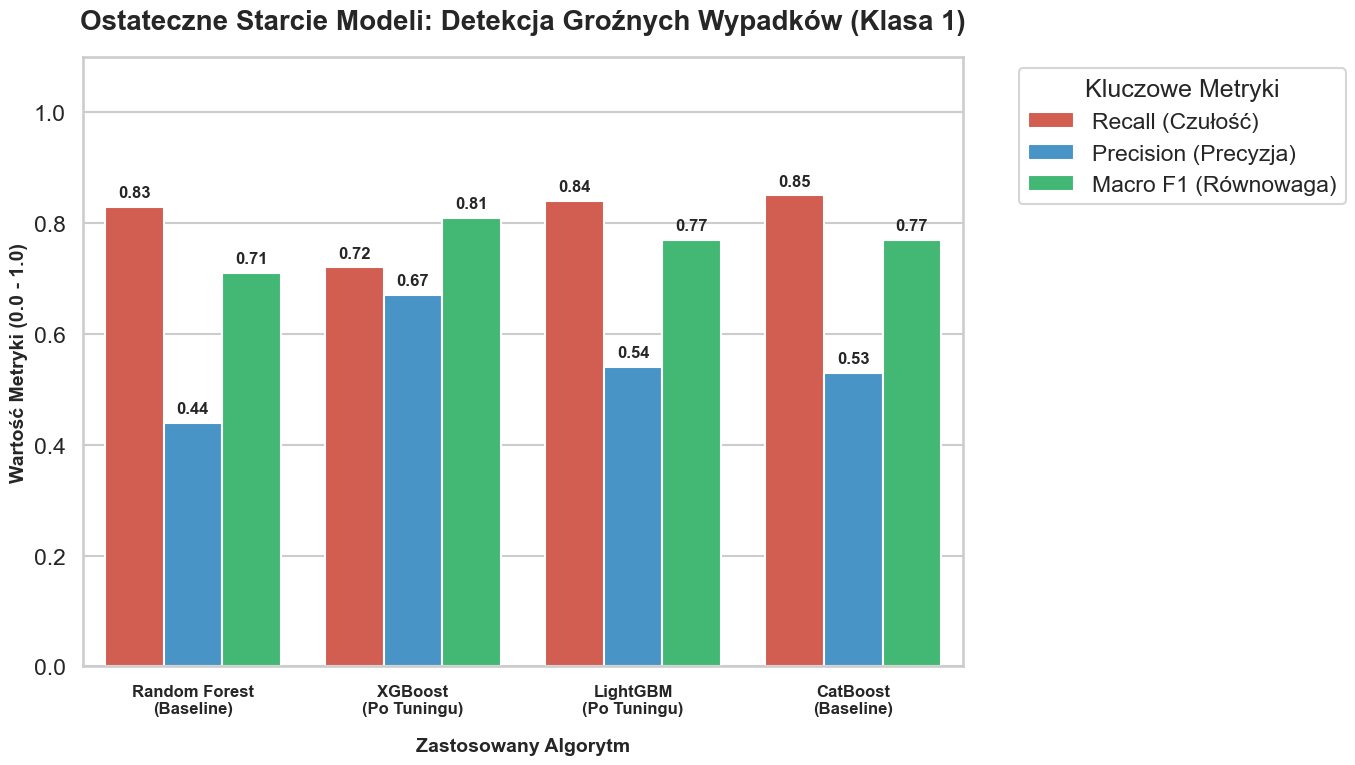

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# 1. Zebranie twardych danych z całego projektu (Klasa 1)
data = {
    'Model': [
        'Random Forest\n(Baseline)', 
        'XGBoost\n(Po Tuningu)', 
        'LightGBM\n(Po Tuningu)', 
        'CatBoost\n(Baseline)' 
    ],
    'Recall (Czułość)': [0.83, 0.72, 0.84, 0.85],
    'Precision (Precyzja)': [0.44, 0.67, 0.54, 0.53],
    'Macro F1 (Równowaga)': [0.71, 0.81, 0.77, 0.77]
}

df_results = pd.DataFrame(data)

# 2. Przygotowanie danych do wykresu (format "długi" dla Seaborn)
df_melted = df_results.melt(id_vars='Model', var_name='Metryka', value_name='Wynik')

# 3. Konfiguracja i rysowanie wykresu
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_context("talk")

# Tworzymy grupowany wykres słupkowy
ax = sns.barplot(
    x='Model', 
    y='Wynik', 
    hue='Metryka', 
    data=df_melted, 
    palette=['#e74c3c', '#3498db', '#2ecc71'] 
)

# 4. Personalizacja i estetyka
plt.title('Ostateczne Starcie Modeli: Detekcja Groźnych Wypadków (Klasa 1)', fontsize=20, pad=20, fontweight='bold')

# Zmniejszamy minimalnie czcionkę na osi X dla bezpieczeństwa
plt.xticks(fontsize=12, fontweight='bold')
plt.xlabel('Zastosowany Algorytm', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Wartość Metryki (0.0 - 1.0)', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(title='Kluczowe Metryki', bbox_to_anchor=(1.05, 1), loc='upper left')

# Dodanie wartości liczbowych nad słupkami
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'bottom', 
                    xytext = (0, 5), 
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Ostateczny Werdykt i Decyzja

Wykres ewaluacyjny doskonale obrazuje kompromis między czułością a precyzją (Precision-Recall Trade-off) oraz pozwala wyłonić jednoznacznego zwycięzcę w kontekście głównego celu naszej pracy.

Analiza kandydatów:

XGBoost (Po Tuningu): Osiągnął historyczny rekord wskaźnika Macro F1 (0.81) i Precyzji (0.67). Model ten genialnie radzi sobie z odrzucaniem szumu i wyłapywaniem bardzo oczywistych, ciężkich wypadków. Jednakże, z punktu widzenia analizy całokształtu zjawiska, spadek czułości do 0.72 oznacza, że model ten ignoruje aż 28% faktycznie groźnych wypadków, uznając je za niegroźne. To mogłoby zniekształcić ostateczną analizę ważności cech.

LightGBM (Po Tuningu): Doskonały i bardzo stabilny model. Osiągnął świetny kompromis (Recall: 0.84, Precision: 0.54, Macro F1: 0.77). Wyłapuje znacznie więcej groźnych wzorców niż XGBoost. Wymagał jednak kosztownego i czasochłonnego procesu strojenia hiperparametrów.

CatBoost (Baseline): Prawdziwy fenomen tego zestawienia. Wykorzystując potężny mechanizm symetrycznych drzew (oblivious trees), osiągnął genialne wyniki bez żadnej optymalizacji.

Werdykt Analityczny:
Jako ostateczny model, który posłuży nam do głębokiej ekstrakcji wiedzy (Feature Importance), wybieramy Wersję Bazową Algorytmu CatBoost.

Uzasadnienie:

Najwyższa Wykrywalność (Recall 0.85): CatBoost posiada największą zdolność do wyłapywania różnorodnych i skomplikowanych wzorców charakteryzujących groźne wypadki. Z perspektywy analizy czynników jest to kluczowe – model ten "zrozumiał" uwarunkowania niebezpieczeństwa drogowego najlepiej ze wszystkich testowanych algorytmów.

Odporność na przeuczenie: Fakt, że proces optymalizacji (RandomizedSearchCV) nie przyniósł poprawy względem parametrów domyślnych, dowodzi wybitnej zdolności uogólniania tego algorytmu. CatBoost nie "uczy się na pamięć" szumu, lecz znajduje rzeczywiste, uniwersalne reguły drogowe.

Solidny wskaźnik równowagi: Przy rekordowej czułości, model utrzymał solidny wskaźnik Macro F1 (0.77), udowadniając, że jego przewidywania nie opierają się na "strzelaniu na ślepo", lecz na faktycznej identyfikacji kluczowych zmiennych.

Zwycięzca: CatBoost (Categorical Boosting) od Yandex.

## Podsumowanie Etapu Wstępnego (Analiza na próbie 10%)

Niniejszy etap badawczy, zrealizowany na 10-procentowej próbie badawczej, pozwolił na pełne rozpoznanie struktury danych, wstępne testy algorytmów bazowych oraz opracowanie stabilnego i powtarzalnego potoku przetwarzania danych.

Zgodnie z przyjętą strategią projektową, dotychczasowe prace analityczne zostały zamknięte. W kolejnym etapie projektu cały potok przetwarzania i modelowania zostaje przepustowo przeskalowany na pełny, oryginalny zbiór danych US Accidents.

W nowym notatniku badawczym skoncentrujemy się na:

- Pracy na 100% populacji z zachowaniem rygorystycznych mechanizmów inżynieryjnych i optymalizacji pamięci RAM.

- Wdrożeniu zaawansowanych algorytmów z rodziny Gradient Boosting oraz procesie ich strojenia (Hyperparameter Tuning).

- Dalszym ulepszaniu dotychczasowych rozwiązań analitycznych, eksploracji nowych wariantów klasyfikacji oraz pogłębionej ekstrakcji wiedzy.

Przechodzimy do właściwej, pełnoskalowej fazy projektowej w odrębnym pliku roboczym.

